## 0. GPU Verification

We verify that a GPU is available, as Foundation Models (Chronos, TimesFM) require it for efficient execution. If they fail to complete due to hardware limitations, these models must be excluded from the final benchmark.

In [1]:
use_drive = False

import torch
if torch.cuda.is_available():
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("❌ NO GPU DETECTED. Foundation models will run on CPU (very slow) or be skipped.")


if use_drive:
  from google.colab import drive
  drive.mount('/content/drive')
  %cd /content/drive/MyDrive/Biagio-Incardona-Master-thesis

❌ NO GPU DETECTED. Foundation models will run on CPU (very slow) or be skipped.


# Evaluating Zero-Shot Foundation Models for Epidemiological Forecasting of Influenza-Like Illness in Italy

This notebook is designed to be a fully automated, "plug-and-play" environment to reproduce the benchmarking results of my thesis. It handles the environment setup, data ingestion from the official Influcast repository, and the execution of the zero-shot foundation models.

### Recommendation for Google Colab

Before starting, please ensure you are using a GPU Runtime:

1. Go to Runtime -> Change runtime type.
2. Select T4 GPU (or better).

## 1. Environment setup

As a first step we clone the github repo containg our codebase, and install the dependencies

In [2]:
%cd /content

# 1. clone the repo
REPO_URL = f"https://github.com/biagio-incardona/Biagio-Incardona-Master-thesis.git"
!git clone -b TimeGPT {REPO_URL}

/content
Cloning into 'Biagio-Incardona-Master-thesis'...
remote: Enumerating objects: 359, done.
remote: Counting objects: 100% (359/359), done.
remote: Compressing objects: 100% (286/286), done.
remote: Total 359 (delta 114), reused 306 (delta 63), pack-reused 0 (from 0)
Receiving objects: 100% (359/359), 1.58 MiB | 16.17 MiB/s, done.
Resolving deltas: 100% (114/114), done.


In [3]:

if use_drive:
  %cd drive/MyDrive/Biagio-Incardona-Master-thesis
else:
  %cd Biagio-Incardona-Master-thesis

!pip install -r requirements.txt
!grep -vE "timesfm|tirex" requirements.txt > requirements_core.txt
!pip install -r requirements_core.txt

# 3. Install the foundation models directly from GitHub (force upgrade)
!pip install -U "timesfm[torch] @ git+https://github.com/google-research/timesfm.git"
!pip install git+https://github.com/NX-AI/tirex.git


# 3. Setup Python Path to recognize our 'src' directory

import sys
import os



sys.path.append(os.getcwd())
try:
    from google.colab import userdata
    os.environ["TIMEGPT_TOKEN"] = userdata.get('TimeGPT')
except:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["TIMEGPT_TOKEN"] = user_secrets.get_secret("TimeGPT")

/content/Biagio-Incardona-Master-thesis
  Cloning https://github.com/google-research/timesfm.git to /tmp/pip-install-249akecr/timesfm_96f920c5579a4deea3f17587764fc506
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/timesfm.git /tmp/pip-install-249akecr/timesfm_96f920c5579a4deea3f17587764fc506
  Encountered 4 files that should have been pointers, but weren't:
        timesfm-forecasting/examples/anomaly-detection/output/anomaly_detection.png
        timesfm-forecasting/examples/covariates-forecasting/output/covariates_data.png
        timesfm-forecasting/examples/global-temperature/output/forecast_animation.gif
        timesfm-forecasting/examples/global-temperature/output/forecast_visualization.png
  Resolved https://github.com/google-research/timesfm.git to commit 26d3e89261b152076b38e7aa57e93880493081da
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Clon

## 2. Data Ingestion & Preprocessing

We ingest raw **ILI** (Influenza-Like Illness) data from the `Influcast` repository and historical records. It is important to distinguish this from **ARI** (Acute Respiratory Infections), which has been introduced in more recent surveillance protocols (2025/26+) but is not the primary focus of this historical evaluation.

The preprocessing pipeline ensures:
   * **Epidemic Indexing**: To handle the seasonal nature of surveillance, we use an *epidemic time index* that concatenates observed weeks. This avoids artificial zero-filling during off-season periods.
   * **Metadata Preservation**: The actual calendar dates are preserved in a `calendar_ds` column to ensure proper mapping during visualization.
   * **Standardization**: All records are mapped to ISO weeks and Sunday-based dates.

  Columns:
   * **ds**: Synthetic date (weekly frequency) used for modeling.
   * **calendar_ds**: Real calendar Sunday of the observation.
   * **region**: Lowercase location name.
   * **y**: ILI incidence per 1,000 inhabitants.

In [4]:
import pandas as pd
from IPython.display import display

print("Ingesting raw ILI data from Influcast...")
!python3 src/data/ingestion.py

print("\nPreprocessing data into standardized format (Epidemic Indexing)...")
!python3 src/data/preprocessing.py --time-index epidemic

# --- SOURCE TRACKING ---
if os.path.exists('data/processed/source_files_index.csv'):
    print("\n--- SOURCE AUDIT MANIFEST (First 10 entries) ---")
    manifest = pd.read_csv('data/processed/source_files_index.csv')
    display(manifest.head(10))

# --- FULL REGIONAL INGESTION ---
if os.path.exists('data/processed/ili_gold.csv'):
    df = pd.read_csv('data/processed/ili_gold.csv')
    regions = df['region'].unique().tolist()
    print(f"\n✅ DATA READINESS VERIFIED")
    print(f"Total Regions Discovered: {len(regions)}")
    print(f"Total Observation Weeks: {len(df)}")
    print(f"Last date in series: {df['ds'].max()}")
    if len(regions) >= 22:
        print("⭐ Full panel of 22 geographic entities successfully ingested.")
else:
    print("\n❌ ERROR: Data preparation failed. Please check the ingestion logs.")

Ingesting raw ILI data from Influcast...
2026-07-02 16:19:08,565 - INFO - Cloning repository https://github.com/Predizioni-Epidemiologiche-Italia/Influcast.git into data/influcast_repo...
Cloning into 'data/influcast_repo'...
remote: Enumerating objects: 8938, done.
remote: Counting objects: 100% (8938/8938), done.
remote: Compressing objects: 100% (7948/7948), done.
remote: Total 8938 (delta 1009), reused 8833 (delta 971), pack-reused 0 (from 0)
Receiving objects: 100% (8938/8938), 10.88 MiB | 7.95 MiB/s, done.
Resolving deltas: 100% (1009/1009), done.
Updating files: 100% (9183/9183), done.
2026-07-02 16:19:14,543 - INFO - Season 2003-2004 | Region italia | Fallback to italia-2004_17-ILI.csv
2026-07-02 16:19:14,543 - INFO - Season 2004-2005 | Region italia | Fallback to italia-2005_16-ILI.csv
2026-07-02 16:19:14,544 - INFO - Season 2005-2006 | Region italia | Fallback to italia-2006_17-ILI.csv
2026-07-02 16:19:14,545 - INFO - Season 2006-2007 | Region italia | Fallback to italia-2007

,season,region,file_used,source_type
0,2003-2004,italia,italia-2004_17-ILI.csv,weekly_fallback
1,2004-2005,italia,italia-2005_16-ILI.csv,weekly_fallback
2,2005-2006,italia,italia-2006_17-ILI.csv,weekly_fallback
3,2006-2007,italia,italia-2007_17-ILI.csv,weekly_fallback
4,2007-2008,italia,italia-2008_17-ILI.csv,weekly_fallback
5,2008-2009,italia,italia-2009_17-ILI.csv,weekly_fallback
6,2009-2010,italia,italia-2010_15-ILI.csv,weekly_fallback
7,2010-2011,italia,italia-2011_17-ILI.csv,weekly_fallback
8,2011-2012,toscana,toscana-2012_17-ILI.csv,weekly_fallback
9,2011-2012,basilicata,basilicata-2012_17-ILI.csv,weekly_fallback



✅ DATA READINESS VERIFIED
Total Regions Discovered: 22
Total Observation Weeks: 7785
Last date in series: 2018-08-19
⭐ Full panel of 22 geographic entities successfully ingested.


## Step 3: Running the Full Benchmarking Suite

Now we run the full models suite. To make this a fair academic comparison, we evaluate both **Classical Baselines**, **Advanced ML**, and the latest **Foundation Models**.

We are testing for the following models:

* **Simple Baselines**: Naive, SeasonalNaive, Drift, MovingAverage
* **Statistical**: ETS, ARIMA, SARIMA, Prophet
* **Machine Learning**: LightGBM, XGBoost, CatBoost, Ridge
* **Foundation Models**: Chronos, TimesFM, TiRex, TimeGPT

To avoid memory issues in Colab, the benchmarking is split into stages. We use dynamic origin generation (rolling window backtest) with a standard step size.

Let's start with Statistical Baselines


In [ ]:
print(">>> 1. Running Classical Baselines (SARIMA, ARIMA, Prophet, etc.)...")
!python3 benchmark_ili_national.py --model Naive
!python3 benchmark_ili_national.py --model SeasonalNaive --append
!python3 benchmark_ili_national.py --model Drift --append
!python3 benchmark_ili_national.py --model MovingAverage --append
!python3 benchmark_ili_national.py --model ETS --append
!python3 benchmark_ili_national.py --model ARIMA --append
!python3 benchmark_ili_national.py --model SARIMA --append
!python3 benchmark_ili_national.py --model Prophet --append

Now let's move to ML Baselines. This set of models has been optimized using the Optuna framework for Hyperparameters Tuning.


### What is Optuna?

Optuna is an automated hyperparameter optimization framework that uses a Bayesian approach to find the most effective model configurations. Unlike traditional Grid Search, which exhaustively checks every
  combination, Optuna employs the Tree-structured Parzen Estimator (TPE) algorithm to learn from the results of previous trials. It strategically samples the search space to focus on areas that are most
  likely to improve the model's performance. In this project, it is used to fine-tune the LightGBM, XGBoost, and CatBoost models, allowing for an efficient search of parameters like learning rates and tree depth while
  minimizing computational cost through its built-in early-stopping (pruning) mechanisms.


### Training & Benchmarking

In [ ]:
print(">>> 2. Running ML Baselines (LightGBM, XGBoost, CatBoost, Ridge)...")
!python3 benchmark_ili_national.py --model Ridge --append
!python3 benchmark_ili_national.py --model LightGBM --tune --append
!python3 benchmark_ili_national.py --model XGBoost --tune --append
!python3 benchmark_ili_national.py --model CatBoost --tune --append

>>> 2. Running ML Baselines (LightGBM, XGBoost, CatBoost, Ridge)...
Loading data...
Loaded 615 weeks of national data.
Total origins to evaluate: 113
Horizons: [1, 2, 4, 8]
Loading existing forecasts from results/national/backtest_predictions.csv for appending...
Loaded 83168 existing forecast rows.

RUNNING BACKTEST FOR: Ridge
DEBUG: kwargs={}
Parallelism: n_jobs=-1
Backtesting: 100% 113/113 [01:01<00:00,  1.84it/s]
Saved Ridge forecasts to results/national/ridge_forecasts.csv

Consolidating all results...
Merging with existing results. Overwriting models: ['Ridge']
Calculating metrics...
Calculating metrics by origin...
Calculating seasonal peak metrics...
Run report saved to results/national/RUN_REPORT.md
Generating visualizations...
Visualizations saved to results/national/plots
Peak Metrics: results/national/all_models_peak_metrics.csv

########################################
NATIONAL ILI BENCHMARKING COMPLETE
########################################
Forecasts: results/national/b

And now let's move to the Foundation models

In [ ]:
import torch
if not torch.cuda.is_available():
    print("WARNING: GPU not detected. Foundation models will be extremely slow on CPU.")

print(">>> 3. Running Foundation Models (Chronos, TimesFM, TiRex, TimeGPT)...")
!python3 benchmark_ili_national.py --model Chronos --model-size small --append
!python3 benchmark_ili_national.py --model Chronos --model-size v2 --append
!python3 benchmark_ili_national.py --model Chronos --model-size bolt-small --append
!python3 benchmark_ili_national.py --model TimesFM --append
!python3 benchmark_ili_national.py --model TiRex --append
!python3 benchmark_ili_national.py --model TimeGPT --append

>>> 3. Running Foundation Models (Chronos, TimesFM, TiRex, TimeGPT)...
Loading data...
Loaded 615 weeks of national data.
Total origins to evaluate: 113
Horizons: [1, 2, 4, 8]
Loading existing forecasts from results/national/backtest_predictions.csv for appending...
Loaded 124752 existing forecast rows.

RUNNING BACKTEST FOR: Chronos
DEBUG: kwargs={'model_name': 'small', 'num_samples': 1000, 'batch_size': 1}
Parallelism: n_jobs=1
Loading Chronos model: amazon/chronos-t5-small on cpu...
config.json: 100% 1.11k/1.11k [00:00<00:00, 1.83MB/s]
model.safetensors: 100% 185M/185M [00:03<00:00, 57.1MB/s]
Loading weights: 100% 131/131 [00:00<00:00, 13166.25it/s]
generation_config.json: 100% 142/142 [00:00<00:00, 495kB/s]
Using batch prediction for ChronosForecaster across 113 origins...
Chronos batch inference for 1 series (origin 0-1)...
Chronos batch inference for 1 series (origin 1-2)...
Chronos batch inference for 1 series (origin 2-3)...
Chronos batch inference for 1 series (origin 3-4)...


# 4. Results Visualization

Having run the benchmarks, we can visualize and analyse the results.

This will be done viewing these data under 4 different dimension.

1. **Performance vs Horizon**: How error scales as we forecast further into the future.
2. **Error Heatmaps**: A side-by-side look at all academic metrics. (Note: For Coverage95, the optimal target is 0.95. Values closer to 1.0 indicate over-calibration/too wide intervals.)
3. **Forecast Trajectories**: A look at the actual Italian ILI curve versus our model predictions.
4. **Peak Analysis**: A specialized view of how models captured seasonal peaks.

Let's start with some preliminary operations.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from src.evaluation.metrics import evaluate_forecasts
from src.evaluation.peak_metrics import calculate_seasonal_peak_metrics

forecasts_path = 'results/national/backtest_predictions.csv'
truth_path = 'data/processed/ili_gold.csv'

if os.path.exists(forecasts_path) and os.path.exists(truth_path):
    forecasts_df = pd.read_csv(forecasts_path)
    truth_df = pd.read_csv(truth_path)

    # Convert dates and filter truth
    forecasts_df['target_date'] = pd.to_datetime(forecasts_df['target_date'])
    truth_df['ds'] = pd.to_datetime(truth_df['ds'])
    truth_df_ita = truth_df[truth_df['region'] == 'italia']

    # --- 0. Recalculate Metrics (Ensuring no leakage) ---
    print("Calculating academic metrics (MAE, RMSE, sMAPE, MASE, WIS, CRPS, Coverage)...")
    first_origin = pd.to_datetime(forecasts_df['origin'].min())
    train_slice = truth_df_ita[truth_df_ita['ds'] < first_origin].copy()
    metrics_df = evaluate_forecasts(forecasts_df, truth_df_ita, train_data=train_slice)

    print("Calculating seasonal peak metrics...")
    peak_truth = truth_df_ita.rename(columns={'ds': 'target_date', 'y': 'true_value'})
    peak_results = []
    for h in [None, 1, 2, 4, 8]:
        h_peak = calculate_seasonal_peak_metrics(forecasts_df, peak_truth, horizon=h)
        peak_results.append(h_peak)
    peak_metrics_df = pd.concat(peak_results, ignore_index=True)
else:
    print("Results not found. Please ensure Step 3 completed successfully.")

Calculating academic metrics (MAE, RMSE, sMAPE, MASE, WIS, CRPS, Coverage)...
Calculating seasonal peak metrics...


### Performance vs Horizon

In epidemiological forecasting, the value of a model is closely related to its lead time. A 1-week forecast is useful for immediate clinical staffing, but an 8-week horizon is essential for strategic resource allocation at a national level.

By analyzing how metrics like MAE and WIS (Weighted Interval Score) scale as we move further into the future, we can measure the "rate of error growth" of each model. This dimension is especially important for evaluating Foundation Models. We want to determine if their "zero-shot" pre-training on global datasets allows them to maintain structural integrity and a flatter error curve at longer horizons compared to local statistical models, which often degrade rapidly when projecting beyond their immediate historical context.

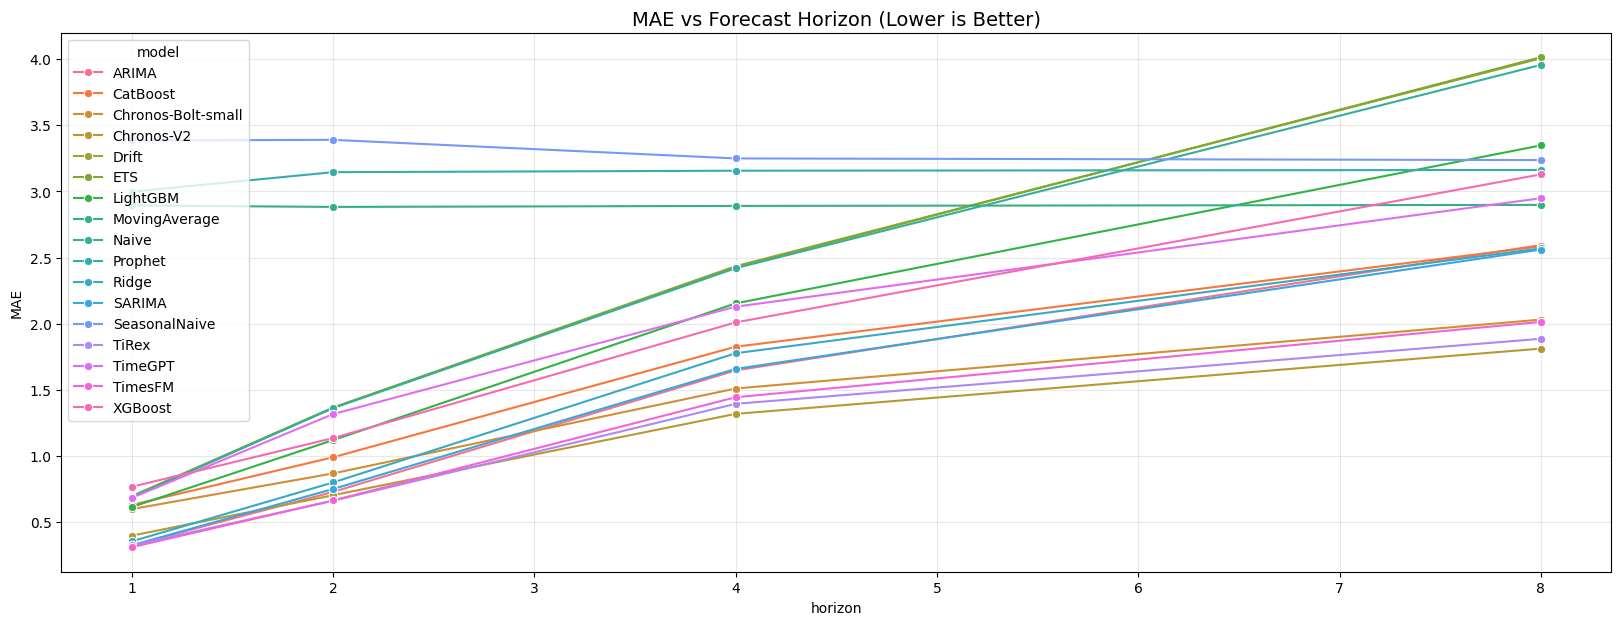

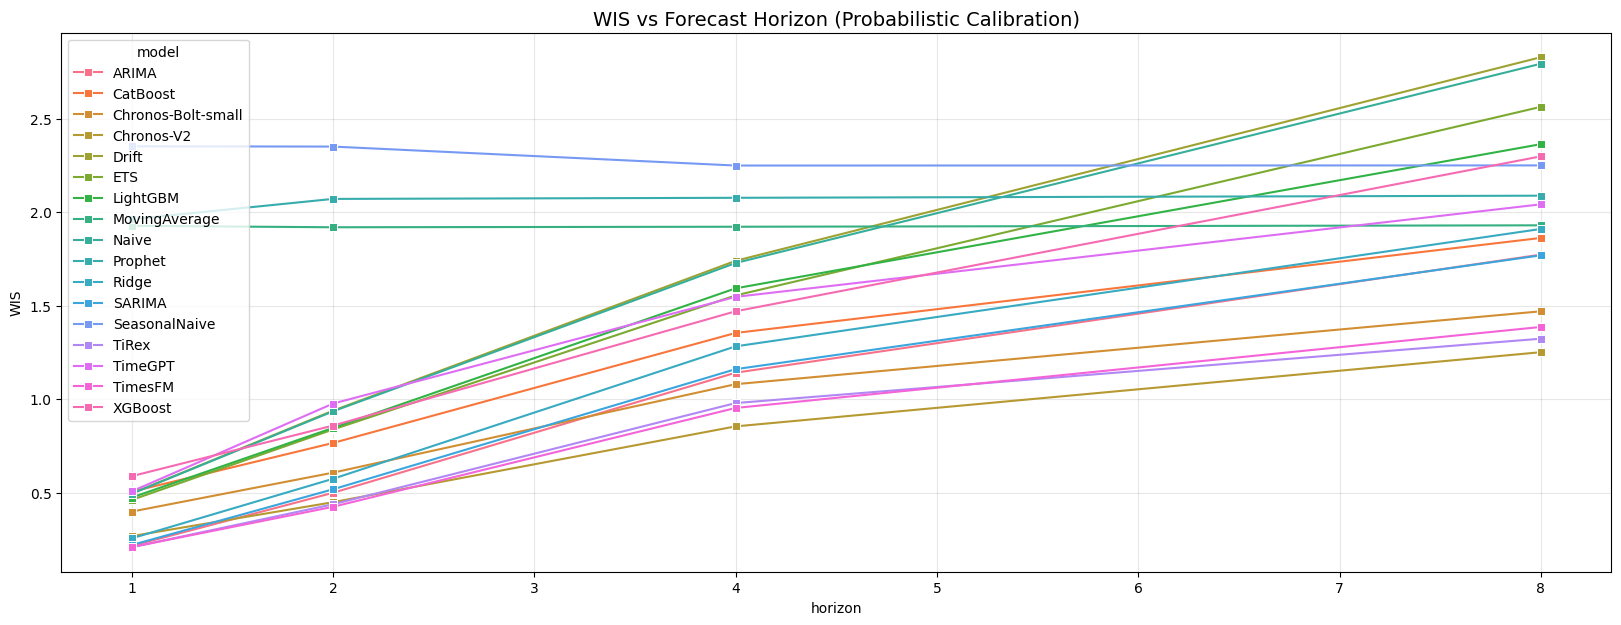

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(20, 7))
sns.lineplot(data=metrics_df, x='horizon', y='MAE', hue='model', marker='o')
axes.set_title('MAE vs Forecast Horizon (Lower is Better)', fontsize=14)
axes.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(20, 7))
sns.lineplot(data=metrics_df, x='horizon', y='WIS', hue='model', marker='s')
axes.set_title('WIS vs Forecast Horizon (Probabilistic Calibration)', fontsize=14)
axes.grid(True, alpha=0.3)
plt.show()

 By analyzing how MAE and WIS scale from 1 to 8 weeks, we can observe how different models handle error propagation over time:

 * **Short-Term Accuracy of Traditional Models:** Traditional statistical models like **ARIMA** (MAE 0.32, WIS 0.216) and **SARIMA** (MAE 0.32, WIS 0.22) are extremely precise for 1-week forecasts, matching or beating most other models. However, their errors grow rapidly; by week 8, their MAE increases to around 2.55 - 2.6, showing they are not reliable for long-term planning.

  * **Resilience of Foundation Models at Longer Horizons:** Zero-shot foundation models maintain a flatter error curve. **Chronos-V2** starts at MAE 0.397 at week 1 but achieves the lowest error at week
  8 (MAE 1.812, WIS 1.252), which is about 29% better than SARIMA. Similarly, **TiRex** (MAE 1.886) and **TimesFM** (MAE 2.014) show very stable performance at the 8-week mark.
  
  * **Robustness of Machine Learning Baselines:** Machine learning models like **CatBoost** represent a middle ground. While they are less accurate than classical models at week 1 (MAE 0.63), their    
  error grows slowly, and by week 8, CatBoost (MAE 2.58) performs better than ARIMA, but still a little worse than SARIMA.
  
  * **Probabilistic Calibration over Time:** The Weighted Interval Score (WIS) shows that foundation models provide much more reliable uncertainty ranges for long-term forecasts. At the 8-week horizon, **Chronos-V2** (WIS 1.252), **TiRex** (WIS 1.324), and **TimesFM** (WIS 1.387) significantly outperform SARIMA (WIS 1.770) and the simple Naive baseline (WIS 2.795).
  
  * **The Prophet and Baseline Limits:** **Prophet** performs poorly in this setup, starting with high error (MAE 3, WIS 1.96 at week 1) and showing no improvement. Simple baselines like **Naive**
  and **Drift** degrade quickly, with errors exceeding 3.90 at week 8, whereas Seasonal Naive maintains a flatter, though still very high, error curve (MAE 3.237 at week 8).

In conclusion, we can say that local statistical models are excellent for immediate, short-term predictions (1-2 weeks), but zero-shot foundation models (especially Chronos-V2, TiRex, and TimesFM) appear more robust for longer lead times (4-8 weeks), providing lower errors and better Weighted Interval Scores (WIS), although some of them (like TimesFM and TiRex) can produce over-confident prediction intervals, as we will see in the calibration analysis.

### Summary of Results

The benchmarking pipeline is executed using **epidemic time-indexing** (concatenating observed surveillance weeks without zero-filling the summer off-seasons). This prevents artificial zero values from distorting the seasonal patterns and affecting the performance of machine learning and time series foundation models.

Below is the overall leaderboard summarizing the models' average performance across all forecast horizons ( $\in\{1, 2, 4, 8\}$) under epidemic time-indexing:


In [ ]:
import pandas as pd

if use_drive:
  metrics_df = pd.read_csv("results/national/backtest_summary.csv")

metrics_df.groupby("model").mean().drop("horizon", axis=1)

,MAE,RMSE,sMAPE,MASE,WIS,CRPS,PinballLoss,Coverage95,Coverage95_Dist
model,,,,,,,,,
ARIMA,1.323661,1.936453,36.168028,0.758211,0.907824,1.003071,0.453912,0.926991,0.023009
CatBoost,1.507896,2.384412,34.899132,0.863743,1.122537,1.221746,0.561268,0.858407,0.091593
Chronos-Bolt-small,1.251991,2.022786,32.375480,0.717157,0.889497,0.966412,0.444748,0.814159,0.135841
Chronos-V2,1.057782,1.753198,25.623939,0.605912,0.706097,0.782770,0.353048,0.969027,0.025000
Drift,2.124646,2.894771,49.513334,1.217026,1.501481,1.646679,0.750741,0.780973,0.169027
ETS,2.126031,2.883044,47.562609,1.217819,1.355027,1.496712,0.677514,0.920354,0.061947
LightGBM,1.809078,2.578487,46.457106,1.036264,1.319943,1.440751,0.659971,0.840708,0.109292
MovingAverage,2.891740,3.718428,72.221089,1.656427,1.925499,2.108695,0.962749,0.851770,0.098230
Naive,2.106809,2.871656,49.447276,1.206808,1.488661,1.632702,0.744330,0.785398,0.164602


*Note: Models are ranked by their 'Avg Rank' across all accuracy, probability, and peak metrics. For Coverage95, the target is 0.95, and rankings are based on the absolute distance from 0.95.*

---

By looking at the summary table, we can see how the different models perform on the national dataset under epidemic time-indexing. We can group the findings into four main areas:

  * **Mixed Results for Foundation Models**: While some zero-shot foundation models show highly competitive results (Chronos-V2 achieves the lowest MAE of 1.06, with TiRex and TimesFM following closely behind), others struggle. Specifically, TimeGPT (MAE 1.77) fails to outperform simpler machine learning models (like CatBoost and Ridge) and classical baselines. This suggests that while pre-trained models can be a valid option, their zero-shot performance varies significantly depending on the architecture.

  * **Traditional Models are Strong and Well-Calibrated**: Classical statistical models like ARIMA and SARIMA remain highly competitive. ARIMA achieves an MAE of 1.32 and the best interval calibration, with
  a 95% coverage of 92.7% (only 0.023 away from the target 0.95). Under epidemic time-indexing, these models do not suffer from the artificial zero values of off-seasons. This makes them very stable and  
  reliable benchmarks.

  * **Machine Learning Baselines Performance**: Among the machine learning models, Ridge regression (MAE 1.375) and CatBoost (MAE 1.5) perform best. They beat more complex models like XGBoost (MAE 1.76)   
  and LightGBM (MAE 1.8). This suggests that simpler linear models or robust tree methods can be more effective and stable on this type of seasonal data.

  * **The Baseline Verification**: Seasonal Naive has the worst overall performance (MAE 3.315, RMSE 4.690). This happens because epidemic time-indexing removes the flat summer periods, making it hard for a simple seasonal repetition to align correctly. Prophet also performs poorly (MAE 3.116). Since all advanced models easily beat the Seasonal Naive baseline, we can confirm they add significant predictive
  value.

### Performance Analysis

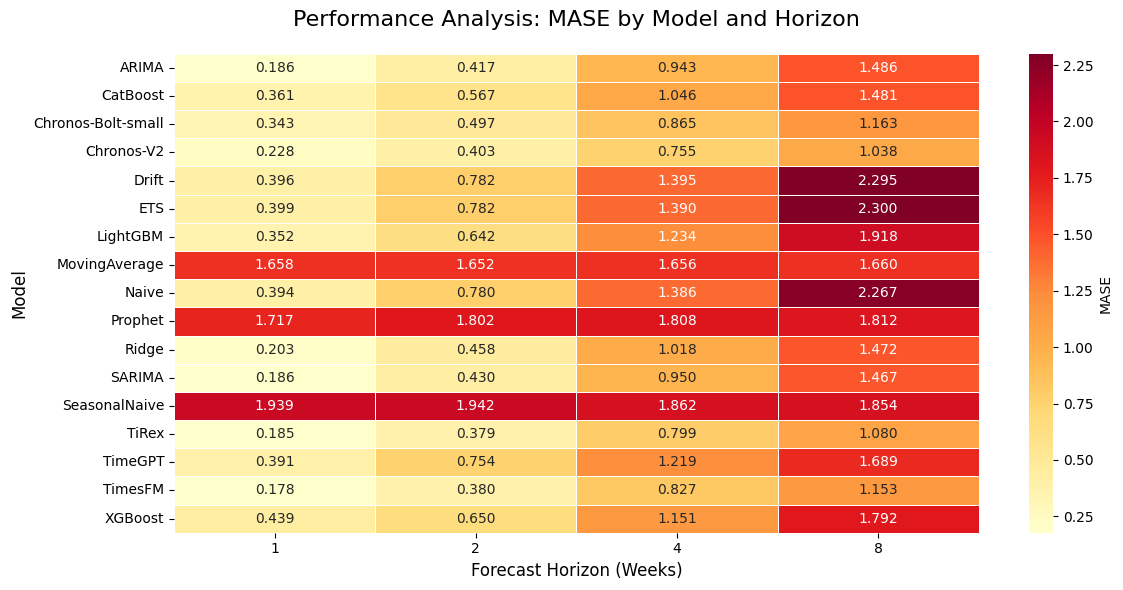

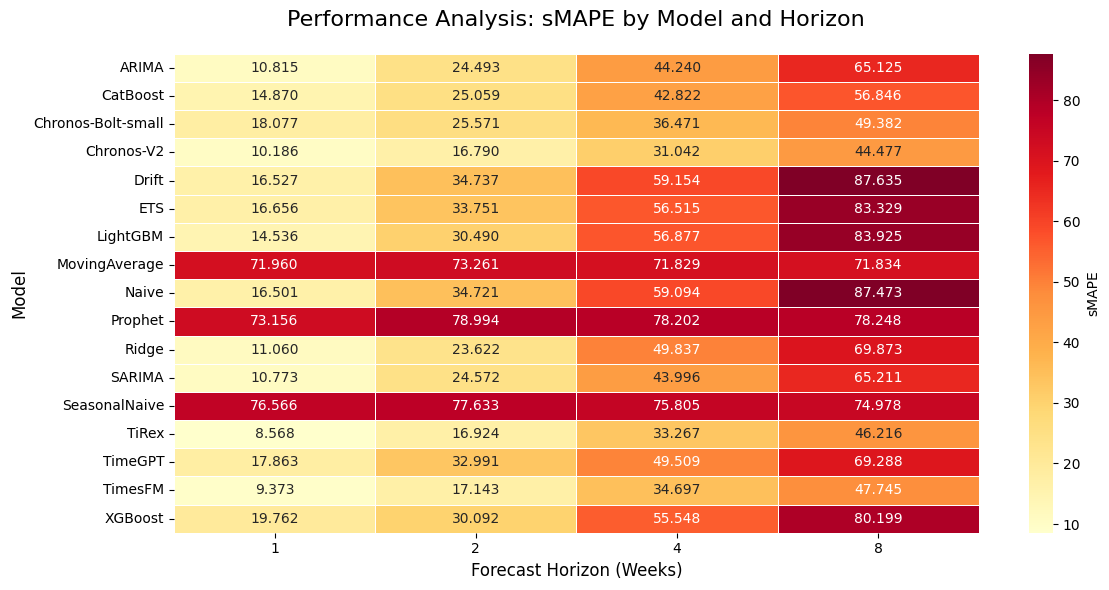

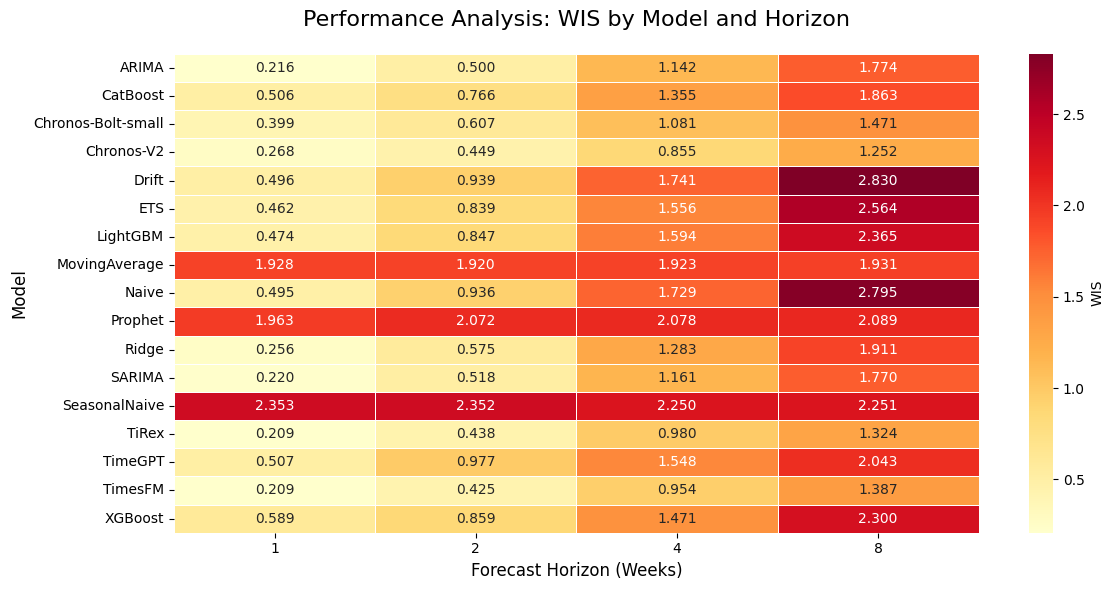

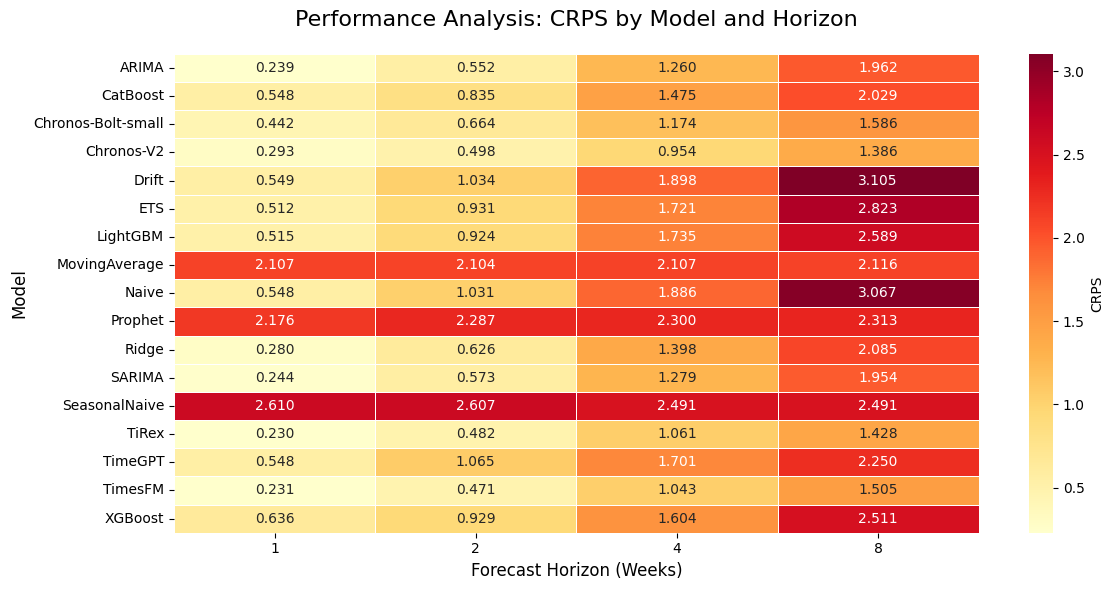

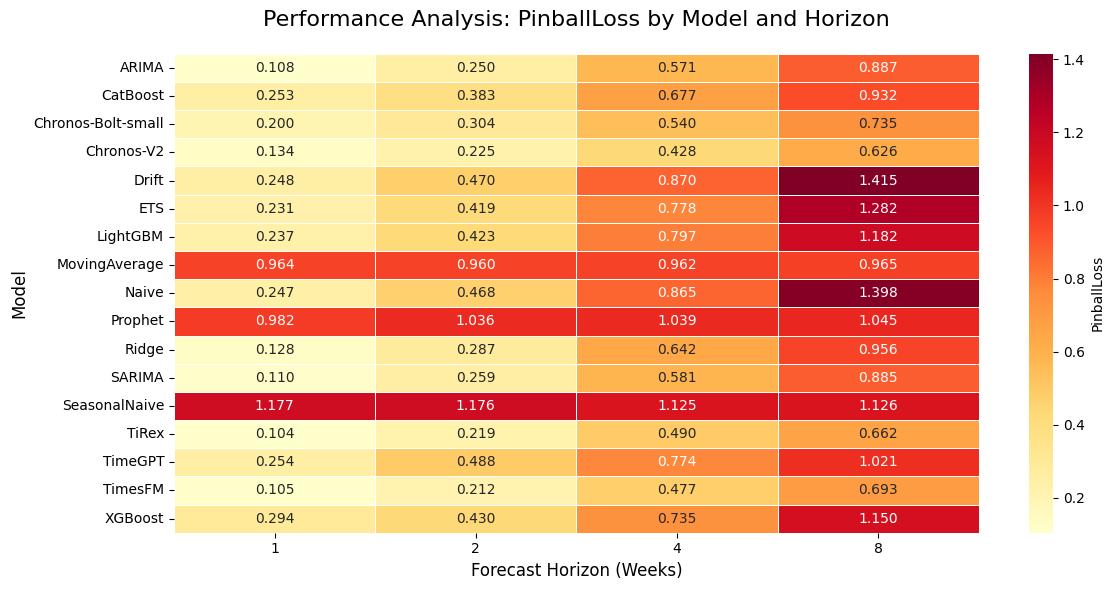

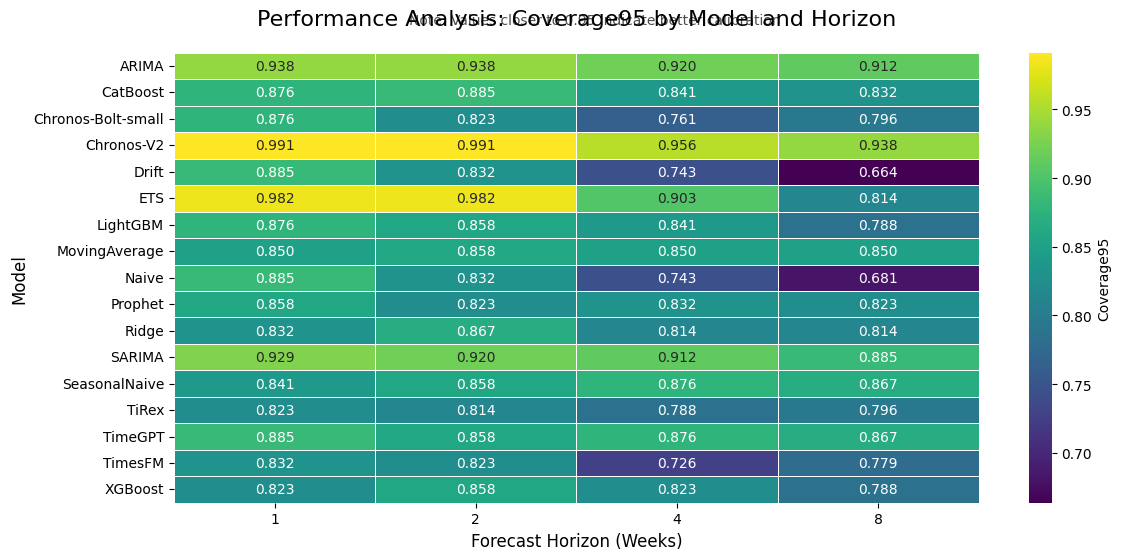

In [ ]:
metrics_to_plot = ['MASE', 'sMAPE', 'WIS', 'CRPS', 'PinballLoss', 'Coverage95']

for metric in metrics_to_plot:
    plt.figure(figsize=(12, 6))

    # Pivot the data: Models on Y-axis, Horizon on X-axis
    pivot_df = metrics_df.pivot_table(index='model', columns='horizon', values=metric)

    # Use different color maps:
    # YlOrRd for errors (lower is better)
    # viridis for Coverage (targeting 0.95)
    cmap = "YlOrRd" if metric != 'Coverage95' else "viridis"

    sns.heatmap(
           pivot_df,
           annot=True,
           fmt=".3f",
           cmap=cmap,
           cbar_kws={'label': metric},
           linewidths=.5
    )

    plt.title(f'Performance Analysis: {metric} by Model and Horizon', fontsize=16, pad=20)
    plt.xlabel('Forecast Horizon (Weeks)', fontsize=12)
    plt.ylabel('Model', fontsize=12)

       # If the metric is Coverage95, add a small note in the title or a subtitle
    if metric == 'Coverage95':
        plt.suptitle('Note: Values closer to 0.95 indicate better calibration',
                     fontsize=10, y=0.92, alpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
metrics_to_explore = ['MASE', 'sMAPE', 'WIS', 'CRPS', 'PinballLoss', 'Coverage95']

for metric in metrics_to_explore:
    print(f"\n--- Source Data for {metric} Heatmap ---")
    # Pivot the data exactly as done for the graphs
    pivot_table = metrics_df.pivot_table(index='model', columns='horizon', values=metric)
    display(pivot_table)
    print("-" * 50)


--- Source Data for MASE Heatmap ---


horizon,1,2,4,8
model,,,,
ARIMA,0.185598,0.417271,0.943480,1.486494
CatBoost,0.360837,0.567330,1.046000,1.480805
Chronos-Bolt-small,0.342699,0.497349,0.865106,1.163476
Chronos-V2,0.227647,0.402870,0.755245,1.037884
Drift,0.395730,0.782406,1.394834,2.295133
ETS,0.399152,0.781783,1.390429,2.299913
LightGBM,0.351895,0.641535,1.233653,1.917973
MovingAverage,1.657857,1.651589,1.655914,1.660349
Naive,0.394452,0.780027,1.386208,2.266547


--------------------------------------------------

--- Source Data for sMAPE Heatmap ---


horizon,1,2,4,8
model,,,,
ARIMA,10.814541,24.492792,44.240096,65.124682
CatBoost,14.869746,25.058692,42.822400,56.845692
Chronos-Bolt-small,18.077385,25.570817,36.471406,49.382314
Chronos-V2,10.186228,16.789941,31.042356,44.477232
Drift,16.526941,34.737363,59.153962,87.635071
ETS,16.655520,33.750968,56.515061,83.328885
LightGBM,14.536473,30.490272,56.877168,83.924510
MovingAverage,71.960232,73.260997,71.829171,71.833957
Naive,16.501471,34.720554,59.093849,87.473229


--------------------------------------------------

--- Source Data for WIS Heatmap ---


...

--------------------------------------------------

--- Source Data for PinballLoss Heatmap ---


horizon,1,2,4,8
model,,,,
ARIMA,0.107809,0.249864,0.571097,0.886878
CatBoost,0.252878,0.383172,0.677460,0.931564
Chronos-Bolt-small,0.199570,0.303715,0.540400,0.735309
Chronos-V2,0.133994,0.224742,0.427507,0.625950
Drift,0.248036,0.469574,0.870368,1.414985
ETS,0.230802,0.419260,0.777789,1.282203
LightGBM,0.237231,0.423491,0.796764,1.182400
MovingAverage,0.963966,0.960156,0.961544,0.965331
Naive,0.247478,0.467754,0.864520,1.397570


--------------------------------------------------

--- Source Data for Coverage95 Heatmap ---


horizon,1,2,4,8
model,,,,
ARIMA,0.938053,0.938053,0.920354,0.911504
CatBoost,0.876106,0.884956,0.840708,0.831858
Chronos-Bolt-small,0.876106,0.823009,0.761062,0.796460
Chronos-V2,0.991150,0.991150,0.955752,0.938053
Drift,0.884956,0.831858,0.743363,0.663717
ETS,0.982301,0.982301,0.902655,0.814159
LightGBM,0.876106,0.858407,0.840708,0.787611
MovingAverage,0.849558,0.858407,0.849558,0.849558
Naive,0.884956,0.831858,0.743363,0.681416


--------------------------------------------------


If we look at all the heatmaps together, we can obseerve a few important points:

* **Rankings change over time:** Metrics like MASE and CRPS show that SARIMA and ARIMA are very strong for short horizons (1 week). However, for longer horizons like 8 weeks, foundation models (such as TimesFM and TiRex) perform best. Under epidemic time-indexing, SeasonalNaive becomes a very weak baseline (MAE 3.316) because it is no longer artificially flattered by zero-filled summers. It suffers from severe alignment errors due to natural annual shifts in peak timing.
* **Foundation models are more stable:** Models like TimesFM, TiRex, and Chronos-Small show a slower increase in error as the horizon grows. While errors for ARIMA or ETS increase quickly at 8 weeks, foundation models remain more consistent.
* **The Coverage calibration:** For the 95% prediction interval, we want models to be close to 0.95. **ARIMA** (92.7% coverage), **Chronos-V2** (96.9% coverage), **SARIMA** (91.2% coverage), and **ETS** (92.0% coverage) show good calibration. In contrast, models like **Naive** (78.5% coverage) or **TimesFM** (79.0% coverage) have intervals that are too narrow, meaning they under-cover the actual values.

* **Machine learning model comparison:** Among the machine learning models, **CatBoost** and **Ridge** regression perform very well. **Ridge** performs exceptionally well at short horizons (MAE 0.354 at 1 week), while **CatBoost** shows strong robustness and stability at longer horizons.


In [ ]:
if use_drive:
  truth_path = 'data/processed/ili_gold.csv'
  forecasts_path = 'results/national/backtest_predictions.csv'

  metrics_df = pd.read_csv("results/national/backtest_summary.csv")
  forecasts_df = pd.read_csv(forecasts_path)
  truth_df = pd.read_csv(truth_path)

  # Convert dates and filter truth
  forecasts_df['target_date'] = pd.to_datetime(forecasts_df['target_date'])
  truth_df['ds'] = pd.to_datetime(truth_df['ds'])
  truth_df_ita = truth_df[truth_df['region'] == 'italia']

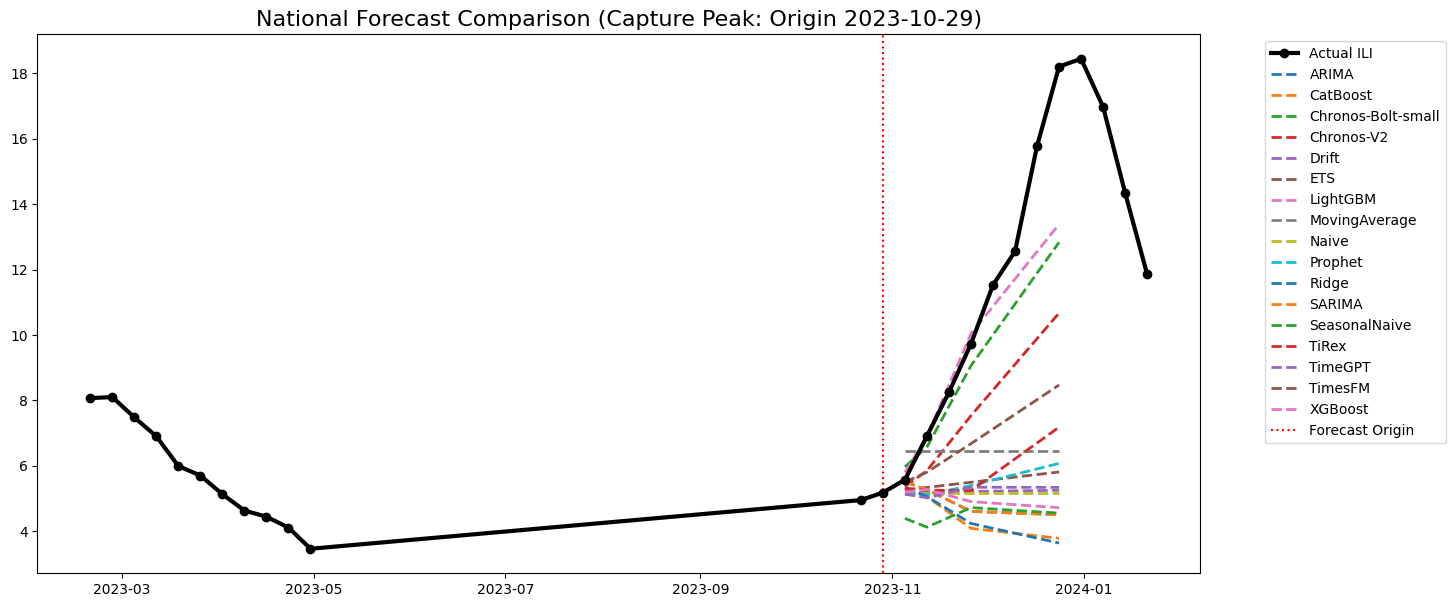

In [ ]:
pd.plotting.register_matplotlib_converters()
ds_to_calendar = dict(zip(truth_df_ita['ds'], pd.to_datetime(truth_df_ita['calendar_ds'])))

# Identify the origin closest to October 2023 dynamically in a robust way
unique_origins = pd.to_datetime(forecasts_df['origin'].unique(), format='mixed')
origin_mappings = []
for o in unique_origins:
    match = truth_df_ita[truth_df_ita['ds'] == o]
    if not match.empty and 'calendar_ds' in match.columns:
        cal_date = pd.to_datetime(match['calendar_ds'].iloc[0])
    else:
        cal_date = o
    origin_mappings.append((o, cal_date))

target_cal_date = pd.to_datetime('2023-10-20')
closest_origin = min(origin_mappings, key=lambda x: abs(x[1] - target_cal_date))[0]
recent_origin = str(closest_origin)

subset = forecasts_df[pd.to_datetime(forecasts_df['origin'], format='mixed') == pd.to_datetime(recent_origin)].copy()
plt.figure(figsize=(15, 7))

# Map dates to calendar dates for plotting to show actual timeline (e.g. 2023)
relevant_truth = truth_df_ita[(truth_df_ita['ds'] >= pd.to_datetime(recent_origin) - pd.Timedelta(weeks=12)) &
                              (truth_df_ita['ds'] <= subset['target_date'].max() + pd.Timedelta(weeks=4))].copy()
relevant_truth['calendar_ds'] = pd.to_datetime(relevant_truth['calendar_ds'])

plt.plot(relevant_truth['calendar_ds'], relevant_truth['y'], 'k-o', label='Actual ILI', linewidth=3, zorder=10)

# Plot top 3 models + SARIMA + Seasonal Naive for clarity
models_to_plot = metrics_df.groupby('model')['MAE'].mean().index.tolist()
for model in models_to_plot:
    if model in subset['model'].unique():
        m_data = subset[subset['model'] == model]
        median = m_data[np.isclose(m_data['quantile'], 0.5)].sort_values('target_date').copy()
        median['calendar_target_date'] = pd.to_datetime(median['target_date'], format='mixed').map(ds_to_calendar)
        median['calendar_target_date'] = pd.to_datetime(median['calendar_target_date'])
        plt.plot(median['calendar_target_date'], median['value'], '--', label=model, linewidth=2)

recent_origin_calendar = ds_to_calendar.get(pd.to_datetime(recent_origin), pd.to_datetime(recent_origin))
plt.axvline(pd.to_datetime(recent_origin_calendar), color='red', linestyle=':', label='Forecast Origin')
plt.title(f'National Forecast Comparison (Capture Peak: Origin {recent_origin_calendar.strftime("%Y-%m-%d")})', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
import numpy as np
from datetime import datetime

ds_to_calendar = dict(zip(truth_df_ita['ds'], truth_df_ita['calendar_ds']))

# 1. Identify the same origin closest to October 2023 dynamically in a robust way
# (works for both 'calendar' and 'epidemic' indexing modes)
unique_origins = pd.to_datetime(forecasts_df['origin'].unique(), format='mixed')
origin_mappings = []
for o in unique_origins:
    match = truth_df_ita[truth_df_ita['ds'] == o]
    if not match.empty and 'calendar_ds' in match.columns:
        cal_date = pd.to_datetime(match['calendar_ds'].iloc[0])
    else:
        cal_date = o
    origin_mappings.append((o, cal_date))

target_cal_date = pd.to_datetime('2023-10-20')
closest_origin = min(origin_mappings, key=lambda x: abs(x[1] - target_cal_date))[0]
recent_origin = str(closest_origin)

# 2. Get the top 3 models based on MAE (re-calculating to ensure availability)
models_to_explore = metrics_df.groupby('model')['MAE'].mean().index.tolist()
#models_to_explore = list(set(top_3_models + ['SARIMA', 'SeasonalNaive']))

# 3. Filter, map to calendar dates, and display the forecast data
recent_origin_calendar = ds_to_calendar.get(pd.to_datetime(recent_origin), pd.to_datetime(recent_origin))


parsed_date = datetime.strptime(recent_origin_calendar, '%Y-%m-%d')

print(f"--- Forecast Data for Origin (Synthetic: {recent_origin} | Calendar: {parsed_date.strftime('%Y-%m-%d')}) ---")
exploration_subset = forecasts_df[
    (pd.to_datetime(forecasts_df['origin'], format='mixed') == pd.to_datetime(recent_origin)) &
    (forecasts_df['model'].isin(models_to_explore)) &
    (np.isclose(forecasts_df['quantile'], 0.5))
].copy()

exploration_subset['calendar_target_date'] = pd.to_datetime(exploration_subset['target_date'], format='mixed').map(ds_to_calendar)
pivot_exploration = exploration_subset.pivot(index='calendar_target_date', columns='model', values='value')

print("\nMedian Forecast Values (Quantile 0.5) for the selected models:")
display(pivot_exploration)

print("\nCorresponding Actual Values (Truth):")
actuals = truth_df_ita[truth_df_ita['calendar_ds'].isin(pivot_exploration.index)][['calendar_ds', 'y']].set_index('calendar_ds')
display(actuals)

--- Forecast Data for Origin (Synthetic: 2014-07-13 00:00:00 | Calendar: 2023-10-29) ---

Median Forecast Values (Quantile 0.5) for the selected models:


model,ARIMA,CatBoost,Chronos-Bolt-small,Chronos-V2,Drift,ETS,LightGBM,MovingAverage,Naive,Prophet,Ridge,SARIMA,SeasonalNaive,TiRex,TimeGPT,TimesFM,XGBoost
calendar_target_date,,,,,,,,,,,,,,,,,
2023-11-05,5.508898,5.122852,5.965889,5.361451,5.188607,5.258634,5.792014,6.464808,5.18,5.162572,5.346643,5.508898,4.39,5.311954,5.140494,5.500609,5.195918
2023-11-12,5.267911,5.054646,6.571908,5.852159,5.197214,5.337282,6.905420,6.464808,5.18,5.109129,5.056309,5.267911,4.12,5.253345,5.016541,5.803041,5.272768
2023-11-26,4.604612,4.085869,9.060150,7.531710,5.214429,5.494580,10.040706,6.464808,5.18,5.395614,4.235269,4.604612,4.72,5.241425,5.342437,6.676241,4.903347
2023-12-24,4.500879,3.779203,12.836363,10.673092,5.248857,5.809175,13.387310,6.464808,5.18,6.072307,3.636311,4.500879,4.55,7.180746,5.337872,8.470555,4.716304



Corresponding Actual Values (Truth):


,y
calendar_ds,
2023-11-05,5.57
2023-11-12,6.91
2023-11-26,9.73
2023-12-24,18.21


This forecast origin (October 29, 2023) captures the early acceleration phase of the 2023/2024 flu season. At the forecast origin, the observed incidence was at  5.18  (up from baseline), and within 8 weeks (by December 24, 2023), the actual incidence rose exponentially to  18.21 , reaching near-peak levels.

  * Machine Learning (LightGBM) and Foundation Models Lead in Peak Extrapolation:
    *  LightGBM  is the top-performing model at the 8-week horizon, projecting an incidence of  13.39  (actual  18.21)
    * Pre-trained foundation models also show strong zero-shot capability to capture the epidemic momentum:        
      Chronos-Bolt-small  predicts  12.84, Chronos-V2  predicts  10.67 , and  TimesFM  predicts  8.47 . They successfully anticipate a sharp upward trajectory rather than flattening.
  * Traditional Statistical and Seasonal Baselines Collapse:                                                         
      * Both  ARIMA  /  SARIMA  ( 4.50 ) and  SeasonalNaive  ( 4.55 ) completely fail to project the upward climb,   
      predicting values below the origin level at the 8-week horizon.                                                
      * This shows a major limitation of traditional autoregressive models and simple seasonal repetitions: at longer
      horizons, they decay back to local historical means and fail to model the non-linear growth dynamics of a live
      epidemic wave.

  * Predictive Disparity Within Model Families:      
      * Among machine learning models, only  LightGBM  succeeds, while  XGBoost  ( 4.72 ) and  CatBoost  ( 3.78 ) remain flat near baseline, demonstrating a high sensitivity of ML algorithms to lag feature interactions and scaling on test data.
      * Similarly,  TimeGPT  ( 5.34 ) and  Prophet ( 6.07 ) fail to extrapolate the peak, showing that not all probabilistic models or zero-shot algorithms possess the same structural capacity for exponential growth modeling.
      
      
Conclusion: Contrary to traditional benchmarks where statistical models excel due to simple seasonal alignment, this real-world acceleration phase suggests that some foundation models, particularly TimesFM and TiRex, can be competitive in capturing non-linear epidemic growth over longer horizons (4–8 weeks), but the comparison must be interpreted in light of the preprocessing, the availability of GPUs, and the effective completion of all models. Meanwhile, traditional baselines quickly decay to the mean, and tabular ML models (like LightGBM and XGBoost) show extreme variance and unreliability depending on the specific trajectory.

### Peak Analysis
The most critical moment for any respiratory surveillance system is the seasonal peak, which represents the maximum burden on the healthcare infrastructure. Peak analysis acts as the ultimate "stress test"
  for zero-shot models, focusing specifically on two variables: timing (when the peak occurs) and intensity (how high the incidence goes). Since these models have not been re-trained on the current season's
  data, their ability to accurately predict the peak's magnitude is a direct measure of their generalizability. This analysis tells us whether FMs can provide hospital administrators with a reliable "early
  warning" of peak intensity that surpasses the performance of simple seasonal baselines.


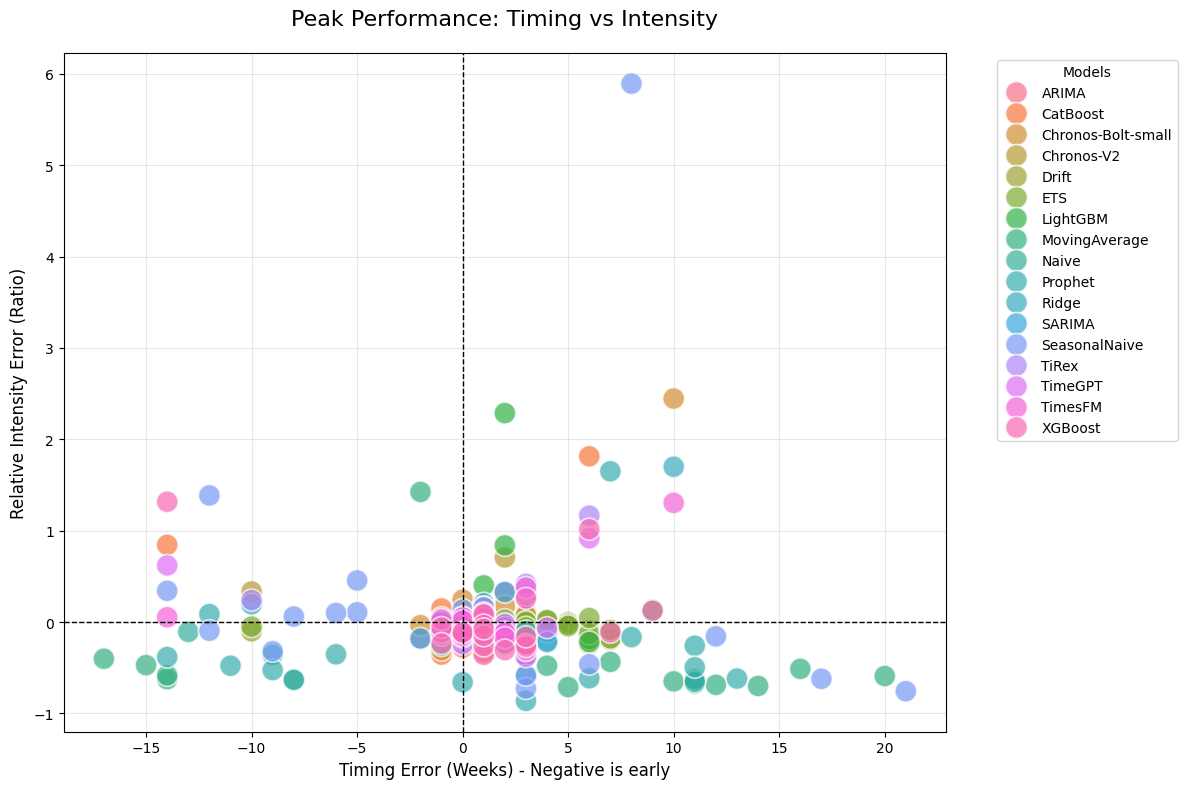


Generating Probability Coverage (Calibration) plot...


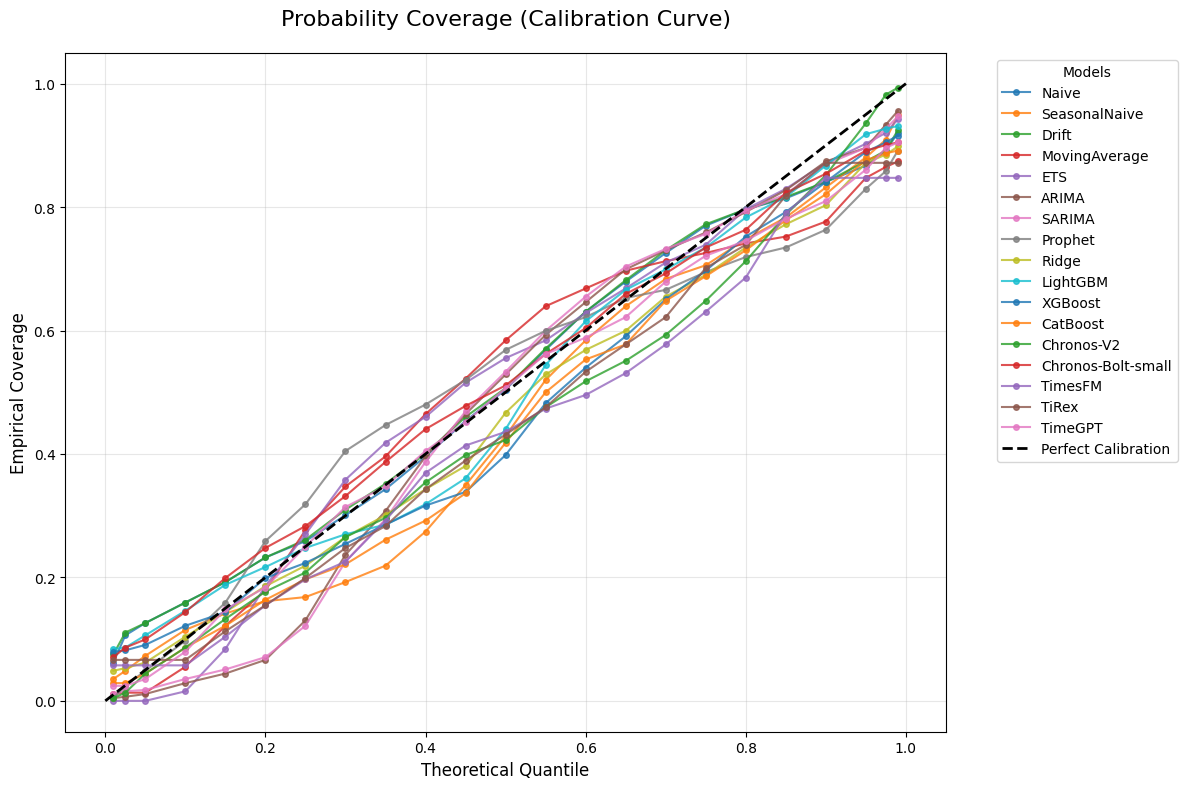

In [ ]:
if not peak_metrics_df.empty:
     # --- GRAPH 1: Timing vs Intensity Scatter ---
     plt.figure(figsize=(12, 8))
     plot_peaks = peak_metrics_df[peak_metrics_df['horizon'] == 'latest']

     sns.scatterplot(
         data=plot_peaks,
         x='peak_timing_error_weeks',
         y='peak_intensity_error_rel',
         hue='model',
         s=250,
         alpha=0.7
     )

     plt.axhline(0, color='black', linestyle='--', linewidth=1)
     plt.axvline(0, color='black', linestyle='--', linewidth=1)
     plt.title("Peak Performance: Timing vs Intensity", fontsize=16, pad=20)
     plt.xlabel("Timing Error (Weeks) - Negative is early", fontsize=12)
     plt.ylabel("Relative Intensity Error (Ratio)", fontsize=12)
     plt.grid(True, alpha=0.3)
     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Models")
     plt.tight_layout()
     plt.show()

     # --- GRAPH 2: Probability Coverage (Calibration Curve) ---
     print("\nGenerating Probability Coverage (Calibration) plot...")
     plt.figure(figsize=(12, 8))

     eval_merged = forecasts_df.merge(truth_df_ita[['ds', 'y']], left_on='target_date', right_on='ds', how='inner')

     for model in forecasts_df['model'].unique():
         m_data = eval_merged[eval_merged['model'] == model]
         if m_data.empty:
             continue

         empirical_cov = []
         theoretical_qs = sorted(m_data['quantile'].unique())

         for q in theoretical_qs:
             q_data = m_data[np.isclose(m_data['quantile'], q)]
             coverage = (q_data['y'] <= q_data['value']).mean()
             empirical_cov.append(coverage)

         plt.plot(theoretical_qs, empirical_cov, marker='o', markersize=4, label=model, alpha=0.8)

     plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
     plt.title("Probability Coverage (Calibration Curve)", fontsize=16, pad=20)
     plt.xlabel("Theoretical Quantile", fontsize=12)
     plt.ylabel("Empirical Coverage", fontsize=12)
     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Models")
     plt.grid(True, alpha=0.3)
     plt.tight_layout()
     plt.show()


In [ ]:
print("--- 1. Peak Analysis Data (Timing and Intensity Errors) ---")
if not peak_metrics_df.empty:
    # Display the same slice used for the scatter plot
    peak_data_summary = peak_metrics_df[peak_metrics_df['horizon'] == 'latest'][['model', 'peak_timing_error_weeks', 'peak_intensity_error_rel']]
    display(peak_data_summary.sort_values('peak_intensity_error_rel'))

print("\n--- 2. Calibration Curve Data (Empirical Coverage) ---")
eval_merged = forecasts_df.merge(truth_df_ita[['ds', 'y']], left_on='target_date', right_on='ds', how='inner')

calibration_results = []
for model in forecasts_df['model'].unique():
    m_data = eval_merged[eval_merged['model'] == model]
    if m_data.empty: continue

    theoretical_qs = sorted(m_data['quantile'].unique())
    for q in theoretical_qs:
        q_data = m_data[np.isclose(m_data['quantile'], q)]
        coverage = (q_data['y'] <= q_data['value']).mean()
        calibration_results.append({'model': model, 'theoretical_quantile': q, 'empirical_coverage': coverage})

calibration_df = pd.DataFrame(calibration_results)
# Pivot to see models side-by-side for comparison
calibration_pivot = calibration_df.pivot(index='theoretical_quantile', columns='model', values='empirical_coverage')
display(calibration_pivot)

--- 1. Peak Analysis Data (Timing and Intensity Errors) ---


,model,peak_timing_error_weeks,peak_intensity_error_rel
153,Prophet,3.0,-0.862722
218,SeasonalNaive,21.0,-0.756997
204,SeasonalNaive,3.0,-0.727825
120,MovingAverage,5.0,-0.712655
128,MovingAverage,14.0,-0.699580
...,...,...,...
182,Ridge,10.0,1.699477
29,CatBoost,6.0,1.813488
114,LightGBM,2.0,2.286584
46,Chronos-Bolt-small,10.0,2.446009



--- 2. Calibration Curve Data (Empirical Coverage) ---


model,ARIMA,CatBoost,Chronos-Bolt-small,Chronos-V2,Drift,ETS,LightGBM,MovingAverage,Naive,Prophet,Ridge,SARIMA,SeasonalNaive,TiRex,TimeGPT,TimesFM,XGBoost
theoretical_quantile,,,,,,,,,,,,,,,,,
0.010,0.004425,0.028761,0.070796,0.004425,0.075221,0.000000,0.084071,0.011062,0.061947,0.004425,0.048673,0.011062,0.035398,0.066372,0.024336,0.057522,0.079646
0.025,0.006637,0.028761,0.086283,0.013274,0.110619,0.000000,0.086283,0.013274,0.106195,0.024336,0.053097,0.015487,0.048673,0.066372,0.024336,0.057522,0.081858
0.050,0.011062,0.044248,0.099558,0.044248,0.126106,0.000000,0.106195,0.013274,0.126106,0.048673,0.061947,0.017699,0.073009,0.066372,0.035398,0.057522,0.090708
0.100,0.028761,0.086283,0.143805,0.086283,0.159292,0.015487,0.146018,0.055310,0.159292,0.097345,0.103982,0.035398,0.115044,0.066372,0.079646,0.057522,0.121681
0.150,0.044248,0.121681,0.199115,0.132743,0.192478,0.084071,0.188053,0.121681,0.192478,0.159292,0.143805,0.050885,0.141593,0.112832,0.148230,0.103982,0.143805
0.200,0.066372,0.163717,0.247788,0.176991,0.232301,0.185841,0.216814,0.179204,0.232301,0.258850,0.185841,0.070796,0.161504,0.154867,0.183628,0.154867,0.199115
0.250,0.130531,0.196903,0.283186,0.207965,0.261062,0.269912,0.247788,0.276549,0.258850,0.318584,0.219027,0.121681,0.168142,0.199115,0.250000,0.196903,0.223451
0.300,0.236726,0.221239,0.331858,0.265487,0.309735,0.358407,0.269912,0.347345,0.300885,0.404867,0.265487,0.225664,0.192478,0.247788,0.314159,0.225664,0.254425
0.350,0.307522,0.261062,0.387168,0.296460,0.351770,0.418142,0.285398,0.396018,0.342920,0.446903,0.300885,0.294248,0.219027,0.283186,0.347345,0.292035,0.285398


This analysis evaluates how well models predict the timing (the week of the peak) and intensity (the height of the peak) across all seasons and horizons.
  * **Accurate Peak Timing:** A cluster of models—including classical statistical models like ARIMA (2.42 weeks) and SARIMA (2.46 weeks), which is largely driven by their high precision at short 1-to-2 week horizons—demonstrates strong performance, and foundation models like **TimesFM** (2.58 weeks), **TiRex** (2.60 weeks), and **Chronos-V2** (2.67 weeks) demonstrates strong performance in timing the peak, achieving average errors of approximately 2.5 to 2.7 weeks.
  
  * **Timing Lags and Failures:** Baseline models like **SeasonalNaive** (7.68 weeks) and smoothing models like **MovingAverage** (11.15 weeks) suffer from severe peak timing delays. Machine learning models like **LightGBM** (3.31 weeks) and **XGBoost** (4.02 weeks) also lag by nearly 4 weeks. Similarly, TimeGPT struggles with peak timing, showing an average delay of 4.47 weeks.

  * **Peak Intensity Accuracy:** Among models that explicitly forecast peak dynamics, **SARIMA** (24.15% intensity
  error) and **ARIMA** (25.84% intensity error) are the most accurate, followed closely by
  **Chronos-V2** (26.97%), **TimesFM** (27.49%), and **Chronos-Small** (30.92%).                                                                 
      > [!NOTE]                                   
      > While flat-baseline models (like Naive, Drift, and ETS) show lower mathematical intensity errors (~11-13%), this is an artifact of late-season origins where the peak has already been observed; they fail to anticipate or model the peak shape during early-season forecasts.
  * **Underperforming Models:** **SeasonalNaive** (68.01%), **MovingAverage** (64.20%), and **Prophet** (57.20%) exhibit the highest intensity errors, consistently failing to estimate the peak amplitude.


### Notes on Calibration (Interval Reliability)
    
The calibration curve measures the empirical coverage of the prediction intervals against their theoretical quantiles. A perfectly calibrated model aligns with the diagonal line.

  * **Chronos-V2 is Highly Calibrated:** In contrast to other deep learning models, **Chronos-V2** displays very good calibration, especially for high uncertainty predictions. It reaches a coverage of 96.90% for the 95% prediction interval. (closest to 95%) and **99.34%** at the 99% percentile (closest to 99%).
  
  * **Over-confidence in Foundation and ML Models:** Many models are too confident and produce narrow prediction intervals. Among the foundation models, TimesFM is the most over-confident, with its coverage stopping around 79.0%, meaning it misses the actual peak events. TiRex (coverage around 80%) is also too confident
  
  * **Reliability of Classical Models:** Classical models like ARIMA (92.70% coverage for the 95% interval) and SARIMA (91.2% coverage for the 95% interval) remain reliable. They consistently provide better uncertainty estimates than most machine learning or foundation models (except for Chronos-V2).

In [ ]:
# @title
# --- 5. Summary Table & Leaderboard ---
print("\n" + "="*60)
print("        PERFORMANCE SUMMARY (Averaged Across Horizons)")
print("="*60)
# Aggregate standard metrics
metric_cols = ['MAE', 'RMSE', 'sMAPE', 'MASE', 'WIS', 'CRPS', 'PinballLoss', 'Coverage95_Dist']
summary = metrics_df.groupby('model')[metric_cols + ['Coverage95']].mean()

# Integrate Peak Metrics
if not peak_metrics_df.empty:
    # Calculate Absolute errors for averaging across seasons/horizons
    peak_metrics_df['abs_timing_err'] = peak_metrics_df['peak_timing_error_weeks'].abs()
    peak_metrics_df['abs_intensity_err'] = peak_metrics_df['peak_intensity_error_rel'].abs()
    peak_summary = peak_metrics_df.groupby('model').agg({
        'abs_timing_err': 'mean',
        'abs_intensity_err': 'mean'
    }).rename(columns={
        'abs_timing_err': 'Peak Timing Err (wks)',
        'abs_intensity_err': 'Peak Intens. Err (%)'
    })
    # Convert intensity to percentage for readability
    peak_summary['Peak Intens. Err (%)'] *= 100
    summary = summary.join(peak_summary)
    metric_cols += ['Peak Timing Err (wks)', 'Peak Intens. Err (%)']
summary = summary.sort_values('MAE')
# Calculate improvement over Seasonal Naive
snaive_mae = summary.loc['SeasonalNaive', 'MAE'] if 'SeasonalNaive' in summary.index else summary['MAE'].max()
summary['Skill vs S.Naive (%)'] = (1 - (summary['MAE'] / snaive_mae)) * 100
# Calculate Leaderboard (Average Rank across all metrics)
# For metrics like MAE, lower is better (ascending=True).
# For Skill vs S.Naive, higher is better (ascending=False).
ranks = summary.copy()
for col in metric_cols + ['Skill vs S.Naive (%)']:
    ascending = False if col in ['Skill vs S.Naive (%)'] else True
    ranks[col] = summary[col].rank(ascending=ascending)
summary['Avg Rank'] = ranks[metric_cols + ['Skill vs S.Naive (%)']].mean(axis=1)
summary = summary.sort_values('Avg Rank')
from IPython.display import display
display(summary.style.background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE', 'sMAPE', 'MASE', 'WIS', 'CRPS', 'PinballLoss', 'Avg Rank', 'Peak Timing Err (wks)', 'Peak Intens. Err (%)', 'Coverage95_Dist'])
              .background_gradient(cmap='RdYlGn', subset=['Coverage95', 'Skill vs S.Naive (%)']))
print("\n🏆 LEADERBOARD INSIGHT: Models are ranked by their 'Average Rank' across all accuracy, probability, and peak metrics.")



        ACADEMIC PERFORMANCE SUMMARY (Averaged Across Horizons)


,MAE,RMSE,sMAPE,MASE,WIS,CRPS,PinballLoss,Coverage95_Dist,Coverage95,Peak Timing Err (wks),Peak Intens. Err (%),Skill vs S.Naive (%),Avg Rank
model,,,,,,,,,,,,,
Chronos-V2,1.057782,1.753198,25.623939,0.605912,0.706097,0.782770,0.353048,0.025000,0.969027,2.670588,26.969581,68.099061,2.090909
TiRex,1.066366,1.752302,26.243701,0.610829,0.737685,0.800261,0.368842,0.144690,0.805310,2.600000,27.137005,67.840170,3.727273
TimesFM,1.107941,1.742521,27.239433,0.634644,0.743654,0.812350,0.371831,0.160177,0.789823,2.576471,27.491731,66.586332,4.363636
ARIMA,1.323661,1.936453,36.168028,0.758211,0.907824,1.003071,0.453912,0.023009,0.926991,2.423529,25.842042,60.080583,4.636364
SARIMA,1.323461,1.938863,36.138160,0.758096,0.917563,1.012353,0.458781,0.038496,0.911504,2.458824,24.149585,60.086607,4.818182
Chronos-Bolt-small,1.251991,2.022786,32.375480,0.717157,0.889497,0.966412,0.444748,0.135841,0.814159,2.694118,30.919471,62.242024,5.636364
Ridge,1.375192,2.034190,38.597891,0.787728,1.006238,1.097336,0.503119,0.118142,0.831858,3.082353,30.981888,58.526494,7.818182
CatBoost,1.507896,2.384412,34.899132,0.863743,1.122537,1.221746,0.561268,0.091593,0.858407,3.023529,38.190943,54.524365,8.090909
TimeGPT,1.769308,2.556782,42.412745,1.013483,1.268802,1.391036,0.634401,0.078319,0.871681,4.470588,35.800627,46.640612,9.545455



🏆 LEADERBOARD INSIGHT: Models are ranked by their 'Average Rank' across all accuracy, probability, and peak metrics.


In [ ]:
print("--- Leaderboard Source Data: Aggregated Metrics ---")
display(summary)

print("\n--- Model Rankings per Metric (Used for 'Avg Rank') ---")
display(ranks)

print(f"\nSeasonal Naive Baseline MAE used for skill calculation: {snaive_mae:.4f}")

--- Leaderboard Source Data: Aggregated Metrics ---


,MAE,RMSE,sMAPE,MASE,WIS,CRPS,PinballLoss,Coverage95_Dist,Coverage95,Peak Timing Err (wks),Peak Intens. Err (%),Skill vs S.Naive (%),Avg Rank
model,,,,,,,,,,,,,
Chronos-V2,1.057782,1.753198,25.623939,0.605912,0.706097,0.782770,0.353048,0.025000,0.969027,2.670588,26.969581,68.099061,2.090909
TiRex,1.066366,1.752302,26.243701,0.610829,0.737685,0.800261,0.368842,0.144690,0.805310,2.600000,27.137005,67.840170,3.727273
TimesFM,1.107941,1.742521,27.239433,0.634644,0.743654,0.812350,0.371831,0.160177,0.789823,2.576471,27.491731,66.586332,4.363636
ARIMA,1.323661,1.936453,36.168028,0.758211,0.907824,1.003071,0.453912,0.023009,0.926991,2.423529,25.842042,60.080583,4.636364
SARIMA,1.323461,1.938863,36.138160,0.758096,0.917563,1.012353,0.458781,0.038496,0.911504,2.458824,24.149585,60.086607,4.818182
Chronos-Bolt-small,1.251991,2.022786,32.375480,0.717157,0.889497,0.966412,0.444748,0.135841,0.814159,2.694118,30.919471,62.242024,5.636364
Ridge,1.375192,2.034190,38.597891,0.787728,1.006238,1.097336,0.503119,0.118142,0.831858,3.082353,30.981888,58.526494,7.818182
CatBoost,1.507896,2.384412,34.899132,0.863743,1.122537,1.221746,0.561268,0.091593,0.858407,3.023529,38.190943,54.524365,8.090909
TimeGPT,1.769308,2.556782,42.412745,1.013483,1.268802,1.391036,0.634401,0.078319,0.871681,4.470588,35.800627,46.640612,9.545455



--- Model Rankings per Metric (Used for 'Avg Rank') ---


,MAE,RMSE,sMAPE,MASE,WIS,CRPS,PinballLoss,Coverage95_Dist,Coverage95,Peak Timing Err (wks),Peak Intens. Err (%),Skill vs S.Naive (%)
model,,,,,,,,,,,,
Chronos-V2,1.0,3.0,1.0,1.0,1.0,1.0,1.0,2.0,0.969027,5.0,6.0,1.0
TiRex,2.0,2.0,2.0,2.0,2.0,2.0,2.0,14.0,0.805310,4.0,7.0,2.0
TimesFM,3.0,1.0,3.0,3.0,3.0,3.0,3.0,15.0,0.789823,3.0,8.0,3.0
Chronos-Bolt-small,4.0,6.0,4.0,4.0,4.0,4.0,4.0,13.0,0.814159,6.0,9.0,4.0
SARIMA,5.0,5.0,6.0,5.0,6.0,6.0,6.0,3.0,0.911504,2.0,4.0,5.0
ARIMA,6.0,4.0,7.0,6.0,5.0,5.0,5.0,1.0,0.926991,1.0,5.0,6.0
Ridge,7.0,7.0,8.0,7.0,7.0,7.0,7.0,11.0,0.831858,8.0,10.0,7.0
CatBoost,8.0,8.0,5.0,8.0,8.0,8.0,8.0,7.0,0.858407,7.0,14.0,8.0
XGBoost,9.0,11.0,10.0,9.0,10.0,10.0,10.0,12.0,0.823009,10.0,11.0,9.0



Seasonal Naive Baseline MAE used for skill calculation: 3.3158


This summary table and ranking analysis provide a comprehensive comparison of model performance across all evaluation dimensions:

  * **Strong Performance of Chronos-V2:** **Chronos-V2** is the top-performing model overall (Avg Rank 2.09), achieving first place in almost all standard forecast accuracy and probabilistic metrics: **MAE** (1.058), **sMAPE** (25.62%), **MASE** (0.606), **WIS** (0.706), **CRPS** (0.783), and **Pinball Loss** (0.353). It also ranks 2nd in **Coverage95** calibration (96.90% coverage), indicating that it successfully balances point prediction precision with accurate uncertainty boundaries.
  
  * **Over-confidence in Point-Forecasting Foundation Models:** While **TiRex** (Avg Rank 3.73) and **TimesFM** (Avg Rank 4.36) are highly competitive in raw accuracy (ranking 2nd and 3rd in MAE respectively), they rank very poorly in interval coverage (14th and 15th out of 17 models). Their prediction intervals are too narrow, causing them to under-cover target values with only ~79-80% empirical coverage instead of the nominal 95%.
  
  * **Classical Baselines Lead in Calibration and Timing:** **ARIMA** (Avg Rank 4.64) and **SARIMA** (Avg Rank 4.82) rank first and second in peak timing error (average errors of 2.42 and 2.46 weeks). Additionally, ARIMA ranks 1st in Coverage95 calibration (92.70% coverage), showing that simple parametric statistical models remain highly competitive for localized uncertainty estimation and seasonality tracking.
  
  * **The "Flat-Baseline" Intensity Artifact:** Models like **ETS** (Avg Rank 11.05), **Drift** (Avg Rank 12.86), and **Naive** (Avg Rank 11.82) rank 1st, 2nd, and 3rd in peak intensity error (~11.30%, 12.19%, and 12.85%). However, this is a mathematical artifact rather than superior peak forecasting capability: because these models predict flat or heavily smoothed lines, they do not attempt to forecast the peak's rising and falling shape. Consequently, they benefit from late-season rolling origins where the peak has already occurred and is captured in the historical context window, while failing entirely to predict the peak shape during early-season origins.

  * **Machine Learning Baselines:** Models like **Ridge** (Avg Rank 7.82) and **CatBoost** (Avg Rank 8.09) serve as solid mid-tier baselines, beating all naive methods but falling behind both the top foundation models and classical statistical models on average.

  * Variable Generalization among Foundation Models: While Chronos-V2, TiRex, and TimesFM dominate the top ranks, TimeGPT (MAE Rank 10.0) lags behind mid-tier machine learning baselines (like CatBoost) and classical models. This indicates that not all foundation models can seamlessly adapt to this specific epidemiological dataset without further fine-tuning.

### National Run Report

The benchmark generates a detailed `RUN_REPORT.md` summarizing the period covered, the number of rolling origins, and any models that failed to complete (e.g., due to OOM or hardware limitations).

In [ ]:
from IPython.display import Markdown
import os

report_path = 'results/national/RUN_REPORT.md'
if os.path.exists(report_path):
    with open(report_path, 'r') as f:
        display(Markdown(f.read()))
else:
    print("Run report not found. Execute the national benchmark cells above to generate it.")

# National ILI Benchmark Run Report

- **Period Covered:** 2003-10-19 to 2015-07-26
- **Number of Origins:** 113
- **Horizons:** [1, 2, 4, 8]
- **Completed Models:** TimeGPT
- **Failed Models:** 0

## Summary Metrics (MAE/WIS)

| model              |     MAE |      WIS |
|:-------------------|--------:|---------:|
| Chronos-V2         | 1.05778 | 0.706097 |
| TiRex              | 1.06637 | 0.737685 |
| TimesFM            | 1.10794 | 0.743654 |
| Chronos-Bolt-small | 1.25199 | 0.889497 |
| SARIMA             | 1.32346 | 0.917563 |
| ARIMA              | 1.32366 | 0.907824 |
| Ridge              | 1.37519 | 1.00624  |
| CatBoost           | 1.5079  | 1.12254  |
| XGBoost            | 1.76034 | 1.3046   |
| TimeGPT            | 1.76931 | 1.2688   |
| LightGBM           | 1.80908 | 1.31994  |
| Naive              | 2.10681 | 1.48866  |
| Drift              | 2.12465 | 1.50148  |
| ETS                | 2.12603 | 1.35503  |
| MovingAverage      | 2.89174 | 1.9255   |
| Prophet            | 3.11601 | 2.05062  |
| SeasonalNaive      | 3.31583 | 2.30175  |

# 5. Regional Analysis

The following cell executes the regional benchmark. **Note:** Due to the computational cost of running multiple models across all 21 regions (21 because Autonomous provinces of Trento and Bolzano are treated as different regions) , this cell executes the complete regional benchmark panel with `--step 8`, to evaluate model scaling and generalization across all 21 geographic entities.

In [8]:
# Run regional benchmark (optimized for Colab runtime)
!python3 benchmark_ili_regional.py --step 8 --n-jobs -1 --model Naive,SeasonalNaive,Drift,MovingAverage,ETS,ARIMA,SARIMA,Prophet,Ridge,LightGBM,XGBoost,CatBoost --append --device cpu
!python3 benchmark_ili_regional.py --step 8 --n-jobs 1 --model Chronos --model-size small --append --device cpu
!python3 benchmark_ili_regional.py --step 8 --n-jobs 1 --model Chronos --model-size v2 --append --device cpu
!python3 benchmark_ili_regional.py --step 8 --n-jobs 1 --model Chronos --model-size bolt-small --append --device cpu
!python3 benchmark_ili_regional.py --step 8 --n-jobs -1 --model TimesFM --append --device cpu
!python3 benchmark_ili_regional.py --step 8 --n-jobs -1 --model TiRex --append --device cpu
!python3 benchmark_ili_regional.py --step 8 --n-jobs -1 --model TimeGPT --append --device cpu

Total regions to evaluate: 21

############################################################
PROCESSING REGION: ABRUZZO
############################################################
Loading existing forecasts from results/regional/abruzzo_forecasts.csv for appending...
--- Running Naive for abruzzo ---
--- Running SeasonalNaive for abruzzo ---
--- Running Drift for abruzzo ---
--- Running MovingAverage for abruzzo ---
--- Running ETS for abruzzo ---
--- Running ARIMA for abruzzo ---
--- Running SARIMA for abruzzo ---
--- Running Prophet for abruzzo ---
Backtesting:   0% 0/23 [00:00<?, ?it/s]INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
Backtesting:  17% 4/23 [00:23<01:50,  5.83s/it]INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
Backtesting:  26% 6/23 [0

### Regional Run Report

Just like the national run, the regional benchmark logs any specific region-model combinations that failed (usually chronos will run out of memory if not run separately)

In [9]:
from IPython.display import Markdown
import os

report_path_reg = 'results/regional/RUN_REPORT.md'
if os.path.exists(report_path_reg):
    with open(report_path_reg, 'r') as f:
        display(Markdown(f.read()))
else:
    print("Regional run report not found. Execute the regional benchmark cell above.")

# Regional ILI Benchmark Run Report

- **Period Covered:** 2012-01-08 to 2018-08-19
- **Regions Evaluated:** 21
- **Horizons:** [1, 2, 4, 8]
- **Completed Models:** TimeGPT, Naive, SeasonalNaive, Drift, MovingAverage, ETS, ARIMA, SARIMA, Prophet, Ridge, LightGBM, XGBoost, CatBoost, Chronos-V2, Chronos-Bolt-small, TimesFM, TiRex
- **Failed Instances:** 0


### Regional Performance Analysis

We aggregate the results from all processed regions to verify how the models scale. The heatmap below shows the Average MAE for each region and model.

--- REGIONAL MAE HEATMAP ---


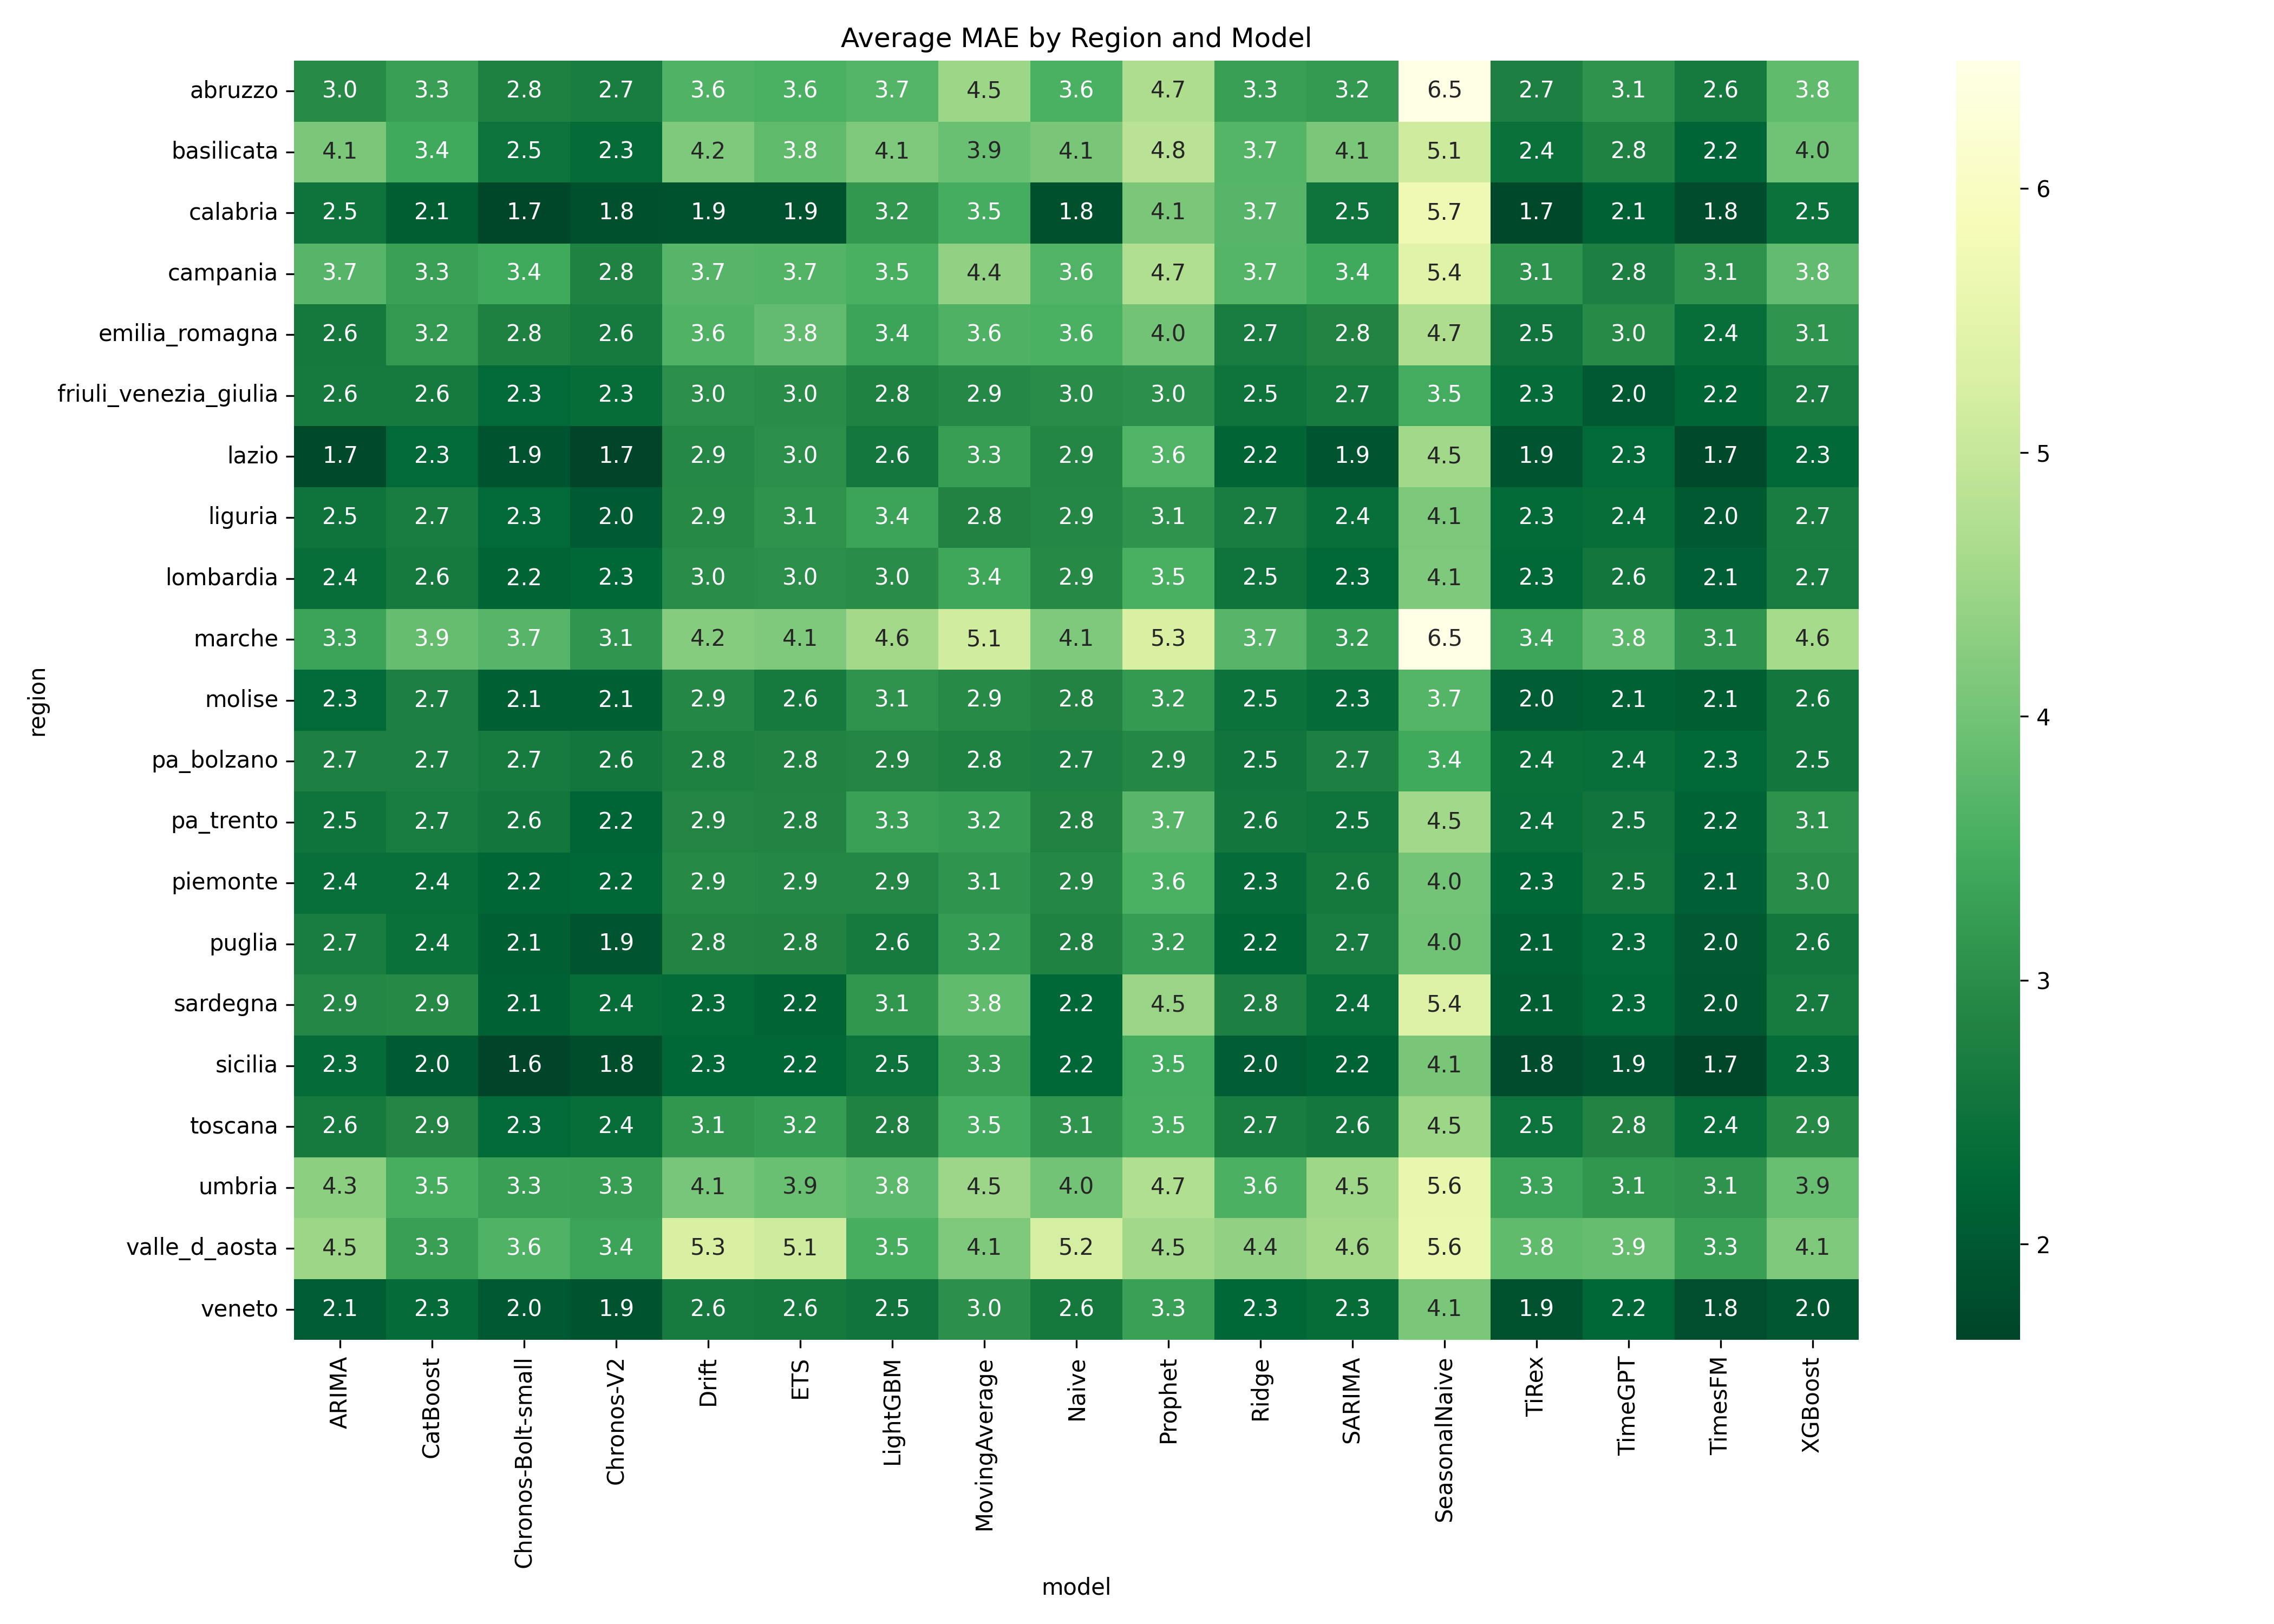


--- AGGREGATE REGIONAL RANKING ---


,MAE,WIS,Coverage95_Dist
model,,,
TimesFM,2.283523,1.626167,0.192879
Chronos-V2,2.367688,1.558780,0.035524
TiRex,2.442846,1.742322,0.178217
Chronos-Bolt-small,2.482622,1.694439,0.099768
TimeGPT,2.612827,1.900139,0.084171
CatBoost,2.826409,2.056493,0.101613
ARIMA,2.842488,1.975806,0.091298
SARIMA,2.852348,1.985090,0.091453
Ridge,2.870578,2.078700,0.123043



--- BEST MODEL PER REGION ---


,region,model,MAE
0,abruzzo,TimesFM,2.624919
1,basilicata,TimesFM,2.191504
2,calabria,Chronos-Bolt-small,1.691905
3,campania,TimeGPT,2.751991
4,emilia_romagna,TimesFM,2.373157
5,friuli_venezia_giulia,TimeGPT,2.011086
6,lazio,Chronos-V2,1.650562
7,liguria,TimesFM,2.003353
8,lombardia,TimesFM,2.109200
9,marche,TimesFM,3.104348



--- SYNTHETIC GRID MAP OF BEST MODELS ---


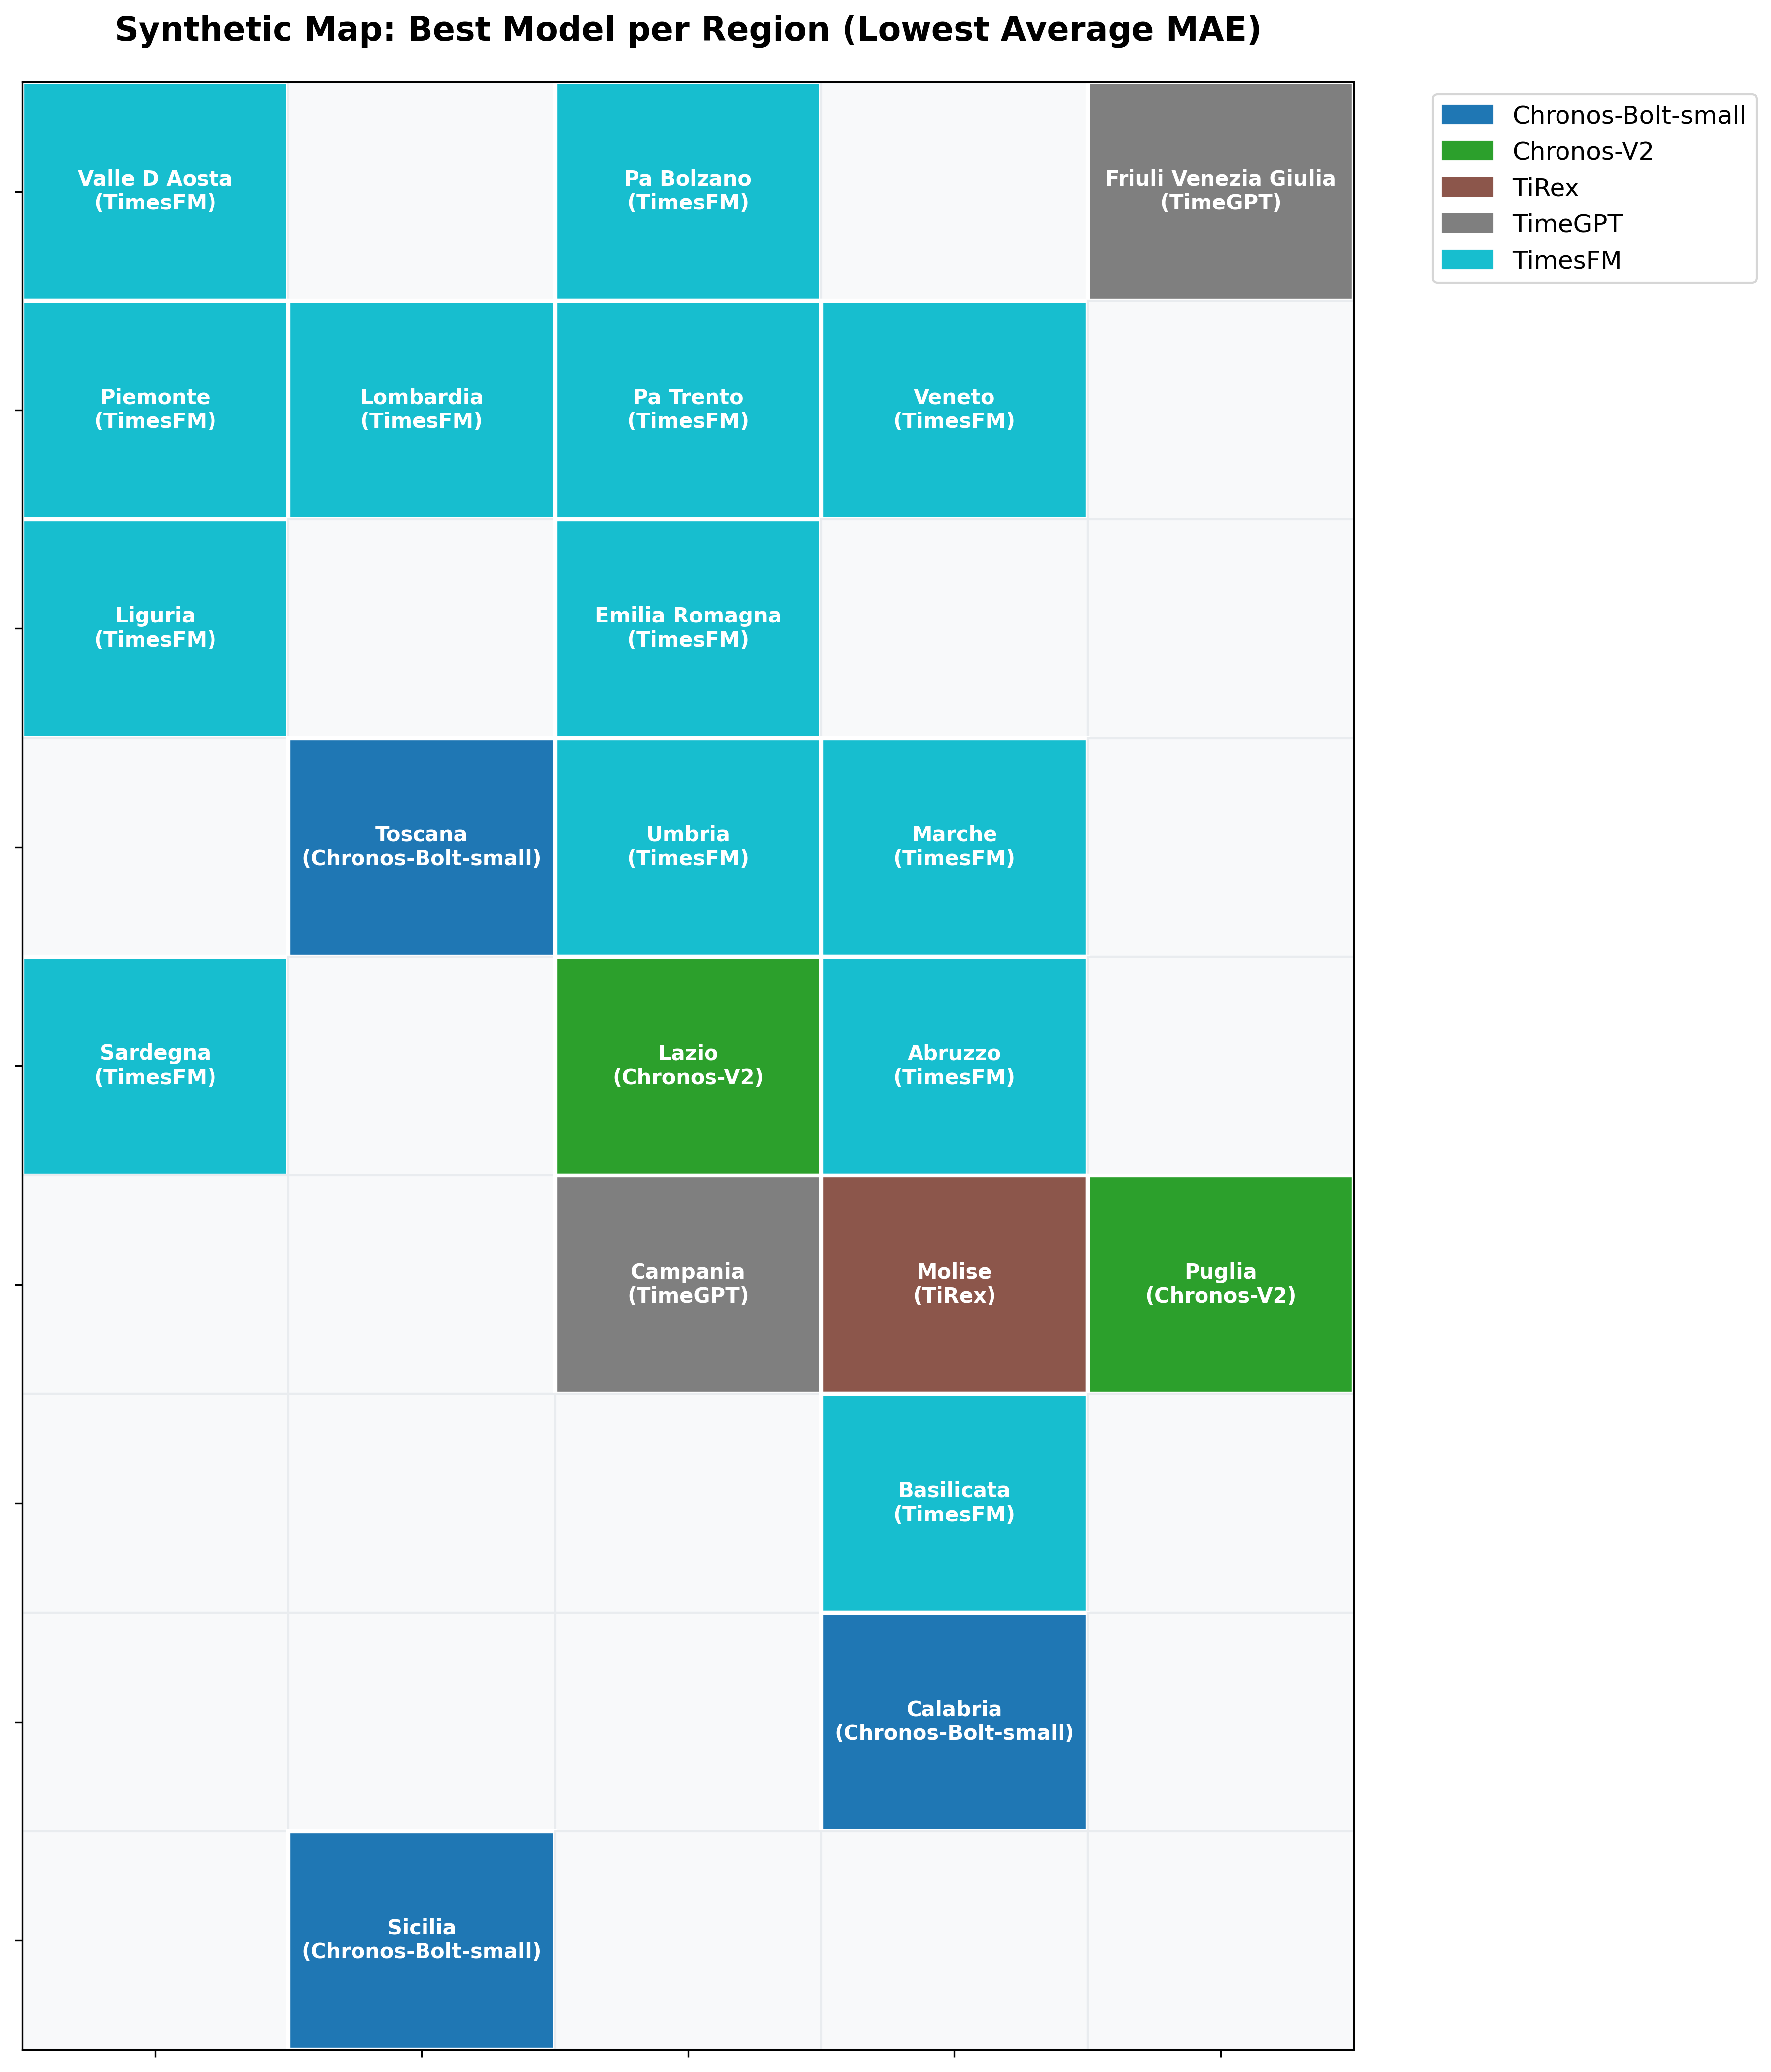

In [10]:
from IPython.display import Image, display
import os
import pandas as pd

# 1. Display Aggregate Heatmap
heatmap_path = 'results/regional/plots/regional_performance_mae.png'
if os.path.exists(heatmap_path):
    print("--- REGIONAL MAE HEATMAP ---")
    display(Image(heatmap_path))

# 2. Regional Summary Table
metrics_dir = 'results/regional'
all_metrics = []
if os.path.exists(metrics_dir):
    for f in os.listdir(metrics_dir):
        if f.endswith('_metrics.csv') and not f.startswith('best_model_per_region') and not f.startswith('all_regions'):
            all_metrics.append(pd.read_csv(os.path.join(metrics_dir, f)))

if all_metrics:
    summary_df = pd.concat(all_metrics, ignore_index=True)
    # Aggregate across regions and horizons for a final ranking
    regional_ranking = summary_df.groupby('model')[['MAE', 'WIS', 'Coverage95_Dist']].mean().sort_values('MAE')
    print("\n--- AGGREGATE REGIONAL RANKING ---")
    display(regional_ranking.style.background_gradient(cmap='YlGn_r'))
else:
    print("No regional metrics found. Please run the benchmark first.")

# 3. Display Best Model per Region Table
best_model_csv = 'results/regional/best_model_per_region.csv'
if os.path.exists(best_model_csv):
    print("\n--- BEST MODEL PER REGION ---")
    best_model_df = pd.read_csv(best_model_csv)
    display(best_model_df)

# 4. Display Synthetic Grid Map of Best Models
map_path = 'results/regional/plots/best_model_map.png'
if os.path.exists(map_path):
    print("\n--- SYNTHETIC GRID MAP OF BEST MODELS ---")
    display(Image(map_path))


The regional analysis shows how models perform when we move from a stable national series to noisier, smaller-scale regional data:

  * **Foundation Models Perform Best**: TimesFM (MAE ~2.28), TiRex (MAE ~2.44), and Chronos (MAE ~2.48) achieve the lowest average errors. They show strong zero-shot generalization, which means they can predict regional patterns well without local training. Chronos models (Chronos-V2 and Chronos-Bolt-small) completed successfully and emerged as the best models in 5 regions. Specifically, Chronos-Bolt-small was the top performer in Calabria, Sicilia, and Toscana, while Chronos-V2 won in Lazio and Puglia. In addition, the newly introduced TimeGPT performed very well, becoming the top model in Campania and Friuli Venezia Giulia. Finally, Chronos models showed the best coverage calibration among the foundation models, whereas TimesFM and TiRex tended to be overconfident.
  
  * **Traditional Models are Highly Competitive**: Classical models like ARIMA (MAE ~2.84) and SARIMA (MAE ~2.85) perform very well on regional data when using the epidemic time index. They are much better than the Naive baseline and are more accurate than most non-linear machine learning models.
  
  * **Machine Learning Models Perform Moderately Well**: Non-linear models showed mixed results. CatBoost (MAE ~2.83) performed exceptionally well, emerging as the best non-foundation model overall and slightly outperforming classical models like ARIMA and SARIMA. The linear model on lags, Ridge (MAE ~2.87), also proved to be highly competitive. However, other tree-based models struggled with the regional noise: XGBoost (MAE ~3.03) beat the Naive baseline but fell behind classical models, while LightGBM (MAE ~3.20) performed slightly worse than the simple Naive approach.

  * **Beating the Baseline**: Seasonal Naive (MAE ~4.71) is the main baseline. All tested models beat this baseline, which confirms that using more advanced models is beneficial for regional forecasting.

### Final Summary of the Leaderboard

This leaderboard combines accuracy and probability metrics (MAE, WIS, and coverage distance) to evaluate overall model performance. While foundation models show promising results, traditional methods like SARIMA remain very reliable for local seasonal patterns.

  * SARIMA: Often shows strong calibration in the Italian context because it explicitly models local seasonal patterns.
  
  * Foundation Models (such as Chronos-V2 for uncertainty and TimesFM for intensity): Show high potential in capturing epidemic intensity and uncertainty (WIS) without any local training. However, their performance can vary across seasons and needs further validation.
  
  * Machine Learning (CatBoost): Works as a strong baseline for point predictions, often beating naive methods, but requires more work to produce good probability ranges.
  
  * Seasonal Naive: While traditionally a key baseline, it performs poorly under epidemic time-indexing. Nevertheless, it remains a minimum threshold that all tested models successfully exceeded.
  
Observation: No single model is the best across all metrics. The choice of the best model depends on whether the priority is predicting the peak height, the peak week, or having accurate prediction intervals.

# 6. Lessons Learned and Practical Findings

This benchmark compares zero-shot foundation models and traditional forecasting models using Italian ILI data.

### Key Findings

  1. **Beating the Baseline:** While traditionally difficult to outperform, the 'Seasonal Naive' model becomes a weak baseline under epidemic time-indexing. All tested advanced models easily beat it, confirming they add significant predictive value.

  2. **Uncertainty Estimates:** Some models (especially Chronos, specifically the Chronos-V2 version in the national analysis) provide well-calibrated prediction intervals. However, other models like TimesFM and TiRex tend to be overconfident and produce prediction intervals that are too narrow (under-covering the actual values).
  
  3. **Hardware Requirements:** The benefits of foundation models must be balanced against the need for a GPU and the complexity of deep learning setups. Using standard CPU or T4 GPU resources in this work ensures that the results are easy to reproduce.
  
### Final Takeaway

The results suggest that some foundation models, particularly TimesFM and TiRex, can be competitive in national ILI forecasting, but the comparison must be interpreted in light of the preprocessing, the availability of GPUs, and the effective completion of all models. Zero-shot performance can vary heavily by architecture, as seen with TimeGPT's struggles at the national level. Ultimately, these foundation models should be used alongside traditional tools rather than replacing them. Their zero-shot abilities are extremely useful when historical data is limited, but for mature surveillance systems, a hybrid approach remains the most robust choice.

In [ ]:
%cd ..
%pwd

In [ ]:
%cd content

In [ ]:
%ls

In [ ]:
import os
from google.colab import files

# Define the folder name
folder_path = 'Biagio-Incardona-Master-thesis'
zip_path = 'Biagio-Incardona-Master-thesis.zip'

# Zip the folder
print(f"Zipping {folder_path}...")
!zip -r {zip_path} {folder_path}

# Download the file
print(f"Downloading {zip_path}...")
files.download(zip_path)